# Student Assessment Analysis

This notebook validates the capability of Large Language Models (LLMs) to assess student performance and identify knowledge gaps.

We focus on a specific student (configurable, defaulted to a struggling student) and analyze their code across three scopes:
1.  **Single Assignment Analysis**: Deep dive into one problem.
2.  **Multi-Assignment Analysis**: Broader view across 5 problems.
3.  **Full History Analysis**: Comprehensive view of all their best attempts.

We apply multiple prompt strategies (Zero-shot, Few-shot, Chain-of-Thought, Curriculum-Aware) to compare insights.

In [3]:
# 1. Configuration and Imports
import json
import time
import importlib
import pandas as pd
from google import genai
from google.genai import types

# Load project modules
import utils.constants
import utils.dataset
import lib.prompts
import lib.llm_batch_analyzer
import lib.normalizer

# Reload to ensure latest code is used
for mod in [utils.constants, utils.dataset, lib.prompts, lib.llm_batch_analyzer, lib.normalizer]:
    importlib.reload(mod)

from utils.constants import GEMINI_API_KEY, FOCUS_PROBLEMS
from utils.dataset import (
    load_topics_json,
    load_problem_descriptions,
    load_joined_datasets,
    get_best_attempts,
)
from lib.prompts import SIMPLE_STRATEGIES, build_curriculum_aware_prompt
from lib.llm_batch_analyzer import format_submissions, clean_json_response
from lib.normalizer import normalize_gap_tag

# Initialize Gemini Client
client = genai.Client(api_key=GEMINI_API_KEY)
# LLM Model Config
MODEL_ID = "gemini-2.5-flash" 

print(f"Environment ready. Using model: {MODEL_ID}")

Environment ready. Using model: gemini-2.5-flash


In [4]:
# 2. Data Loading & Student Selection
# We load the full dataset and identify a target student.

print("Loading joined datasets...")
df = load_joined_datasets()

# Get best attempts (highest score per problem)
best_attempts_df = get_best_attempts(df)

# --- Student Selection Logic ---
# Calculate average score per student to find struggling ones
student_scores = best_attempts_df.groupby("SubjectID")["Score"].mean().sort_values()

# CONFIGURABLE: Set this to a specific SubjectID string to override auto-selection
# e.g., TARGET_STUDENT_ID = "f324..."
TARGET_STUDENT_ID = None 

if TARGET_STUDENT_ID is None:
    # Default: Pick a student with a low average score (< 60%)
    # We also ensure they have enough valid attempts (>= 5) to make the analysis interesting
    
    # OPTIMIZED: Vectorized filtering instead of looping
    submission_counts = best_attempts_df.groupby("SubjectID").size()
    students_with_enough_data = submission_counts[submission_counts >= 5].index
    
    struggling_students = student_scores[student_scores < 0.6].index
    
    # Find intersection: Challenged students who also have enough data
    valid_candidates = [s for s in struggling_students if s in students_with_enough_data]
            
    if valid_candidates:
        TARGET_STUDENT_ID = valid_candidates[0] # Pick the lowest struggling one with enough data
    else:
        # Fallback if no low scorers have enough data
        TARGET_STUDENT_ID = student_scores.index[0]

print(f"\nSELECTED STUDENT: {TARGET_STUDENT_ID}")
student_avg = student_scores.loc[TARGET_STUDENT_ID]
print(f"Student Average Score: {student_avg:.2f}")

# Filter data for this student
student_data = best_attempts_df[best_attempts_df["SubjectID"] == TARGET_STUDENT_ID].copy()
print(f"Total Submissions found for student: {len(student_data)}")
display(student_data.head())

Loading joined datasets...
Main table: 201,570 rows
CodeState table: 69,627 rows
Subject table: 381 rows
Joined dataset: 191,584 rows
Best attempts: 15,375 rows (372 students, 50 problems)

SELECTED STUDENT: 14355
Student Average Score: 0.17
Total Submissions found for student: 5


,SubjectID,ProblemID,Order,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,CourseSectionID,TermID,AssignmentID,...,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,ParentEventID,SourceLocation,Code,X-Grade
9854,14355,13,27835,Java 8; CodeWorkout,2019-02-24T16:09:48,UTC,CS 1114,410.0,spring-2019,439.0,...,Run.Program,0.782609,None,None,None,13-55703,None,None,"public int caughtSpeeding(int speed, boolean i...",0.38
9855,14355,24,141830,Java 8; CodeWorkout,2019-03-08T15:24:23,0,CS 1114,410.0,spring-2019,487.0,...,Run.Program,0.000000,None,None,None,24-53707,None,None,"public int blackjack(int a, int b)\r\n{\r\n ...",0.38
9856,14355,40,174569,Java 8; CodeWorkout,2019-03-24T13:51:00,0,CS 1114,410.0,spring-2019,492.0,...,Run.Program,0.076923,None,None,None,40-32736,None,None,public String getSandwich(String str)\r\n{\r\n...,0.38
9857,14355,41,62381,Java 8; CodeWorkout,2019-04-08T12:49:00,0,CS 1114,410.0,spring-2019,494.0,...,Run.Program,0.000000,None,None,None,41-11359,None,None,public int sum3(int[] nums)\r\n{\r\n return ...,0.38
9858,14355,232,42303,Java 8; CodeWorkout,2019-02-24T16:35:06,UTC,CS 1114,410.0,spring-2019,439.0,...,Run.Program,0.000000,None,None,None,232-52239,None,None,"public String alarmClock(int day, boolean vaca...",0.38


In [9]:
# 3. Setup Prompts and LLM Helper

# Load Curriculum Data for the advanced prompt
topics = load_topics_json()
problem_descriptions = load_problem_descriptions()

# Define Prompt Strategies
def get_curriculum_prompt() -> str:
    # We pass all problems relevant to the student's history or a subset
    # For simplicity, we pass the generic FOCUS_PROBLEMS list or all problems the student attempted
    # Let's pass the specific problems we are analyzing to be precise, or the standard focus set.
    # The original function signature is build_curriculum_aware_prompt(topics, problems, focus_ids)
    return build_curriculum_aware_prompt(topics, problem_descriptions, list(student_data["ProblemID"].unique()))

STRATEGIES = {
    "Zero-Shot": lib.prompts.get_zero_shot_prompt,
    "Few-Shot": lib.prompts.get_few_shot_prompt,
    "Chain-of-Thought": lib.prompts.get_chain_of_thought_prompt,
    "Curriculum-Aware": get_curriculum_prompt,
}

def analyze_submission(submission_row, strategies=STRATEGIES):
    """
    Runs the LLM analysis for a single submission row using all defined strategies.
    Returns a dictionary with results.
    """
    results = {
        "ProblemID": submission_row["ProblemID"],
        "Score": submission_row["Score"],
        "Code": submission_row["Code"],
    }
    
    # Format the submission for the prompt (common format)
    # The existing format_submissions() takes a list of dicts
    submission_dict = submission_row.to_dict()
    formatted_input = lib.llm_batch_analyzer.format_submissions([submission_dict])

    for strategy_name, prompt_func in strategies.items():
        # print(f"  Running {strategy_name}...")
        try:
            system_instr = prompt_func()
            
            # Call Gemini
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=formatted_input,
                config=types.GenerateContentConfig(
                    system_instruction=system_instr,
                    temperature=0.3, # Low temp for deterministic analysis
                    response_mime_type="application/json",
                ),
            )
            
            if response.text:
                parsed = json.loads(lib.llm_batch_analyzer.clean_json_response(response.text))
                results[f"{strategy_name}_Output"] = parsed
                
                # Extract specific fields for cleaner display if needed
                # results[f"{strategy_name}_Gaps"] = parsed.get("knowledge_gaps", [])
            else:
                results[f"{strategy_name}_Output"] = "No Response"

        except Exception as e:
            results[f"{strategy_name}_Output"] = f"Error: {str(e)}"
            
    return results

print("Analysis Helper Configured.")

Analysis Helper Configured.


## Experiment 1: Single Assignment Analysis
We select one representative assignment (e.g., the first one they struggled with) and run a detailed multi-prompt analysis.

In [10]:
# Select one assignment (e.g., first submission with score < 1.0)
struggling_assignments = student_data[student_data["Score"] < 1.0]

if not struggling_assignments.empty:
    target_assignment = struggling_assignments.iloc[0]
else:
    # If they are perfect, just take the first one
    target_assignment = student_data.iloc[0]

print(f"Analyzing Problem {target_assignment['ProblemID']} (Score: {target_assignment['Score']})")
print("Code Snippet:\n" + target_assignment["Code"][:200] + "...")

# Run Analysis
single_result = analyze_submission(target_assignment)

# Display Results
# We convert the single result dict to a DataFrame for better viewing
single_df = pd.DataFrame([single_result])

# Show key columns
display_cols = ["ProblemID", "Score"] + [c for c in single_df.columns if "_Output" in c]
display(single_df[display_cols])

# Print full details for inspection
print("\n--- Detailed Output ---")
for strat in STRATEGIES:
    print(f"\n[{strat} Analysis]:")
    print(json.dumps(single_result.get(f"{strat}_Output"), indent=2))

Analyzing Problem 13 (Score: 0.782609)
Code Snippet:
public int caughtSpeeding(int speed, boolean isBirthday)
{
    if (isBirthday)
    {
        speed = speed + 5;
        if (speed <= 60)
        {
            return(0);
        }
        els...


,ProblemID,Score,Zero-Shot_Output,Few-Shot_Output,Chain-of-Thought_Output,Curriculum-Aware_Output
0,13,0.782609,{'knowledge_gaps': ['Incorrect application of ...,{'knowledge_gaps': ['Code duplication (repeati...,{'reasoning_chain': {'step1_behavior': 'The `c...,"{'student_analysis': [{'student_id': '14355', ..."



--- Detailed Output ---

[Zero-Shot Analysis]:
{
  "knowledge_gaps": [
    "Incorrect application of conditional logic: The student modified the 'speed' variable directly by adding 5 when 'isBirthday' is true, instead of adjusting the comparison thresholds. This leads to an incorrect calculation of the ticket level for birthday scenarios.",
    "Redundant code: The line 'speed = speed;' in the 'else' block serves no functional purpose and indicates a lack of understanding of basic variable assignment or code efficiency.",
    "Code duplication and lack of abstraction: The entire 'if-else if-else' structure for determining the ticket level is duplicated within both branches of the 'isBirthday' check. This demonstrates a missed opportunity to refactor common logic and write more concise, maintainable code."
  ],
  "future_predictions": [
    "Refactoring and code optimization: The student may struggle with identifying and extracting common logic to reduce redundancy and improve code rea

## Experiment 2: Batch Analysis (5 Assignments)
We analyze 5 distinct assignments from the same student to observe patterns across different problems.

In [11]:
# Select 5 best attempts (random sample or first 5)
sample_size = min(5, len(student_data))
sample_assignments = student_data.sample(n=sample_size, random_state=42)

print(f"Running analysis on {len(sample_assignments)} assignments...")

batch_results = []
for idx, row in sample_assignments.iterrows():
    print(f"Processing Problem {row['ProblemID']}...")
    res = analyze_submission(row)
    batch_results.append(res)
    time.sleep(2) # Rate limit politeness

# Convert to DataFrame
exp2_df = pd.DataFrame(batch_results)

# Display Summary
print("\n--- Experiment 2 Results ---")
display(exp2_df[["ProblemID", "Score"] + [c for c in exp2_df.columns if "_Output" in c]])

Running analysis on 5 assignments...
Processing Problem 24...
Processing Problem 232...
Processing Problem 40...
Processing Problem 13...
Processing Problem 41...

--- Experiment 2 Results ---


,ProblemID,Score,Zero-Shot_Output,Few-Shot_Output,Chain-of-Thought_Output,Curriculum-Aware_Output
0,24,0.000000,{'knowledge_gaps': ['Understanding of method r...,{'knowledge_gaps': ['Method signature and retu...,{'reasoning_chain': {'step1_behavior': 'The `b...,"{'student_analysis': [{'student_id': '14355', ..."
1,232,0.000000,{'knowledge_gaps': ['**Recursion Fundamentals*...,{'knowledge_gaps': ['Incorrect use of recursio...,{'reasoning_chain': {'step1_behavior': 'The `a...,"{'student_analysis': [{'student_id': '14355', ..."
2,40,0.076923,{'knowledge_gaps': ['Lack of understanding of ...,{'knowledge_gaps': ['Problem understanding/dec...,{'reasoning_chain': {'step1_behavior': 'The st...,"{'student_analysis': [{'student_id': '14355', ..."
3,13,0.782609,{'knowledge_gaps': ['Misinterpretation of prob...,{'knowledge_gaps': ['Logical error in applying...,{'reasoning_chain': {'step1_behavior': 'The st...,"{'student_analysis': [{'student_id': '14355', ..."
4,41,0.000000,{'knowledge_gaps': ['Basic Java syntax for arr...,{'knowledge_gaps': ['Incorrect syntax for retu...,{'reasoning_chain': {'step1_behavior': 'The st...,"{'student_analysis': [{'student_id': '14355', ..."


## Experiment 3: Full History Analysis
We analyze *all* available valid best attempts for the student to build a comprehensive learning profile.

In [12]:
# Use all student_data
print(f"Running full analysis on ALL {len(student_data)} assignments...")

full_results = []
for idx, row in student_data.iterrows():
    print(f"Processing Problem {row['ProblemID']}...", end=" ")
    start_t = time.time()
    res = analyze_submission(row)
    duration = time.time() - start_t
    print(f"Done ({duration:.1f}s)")
    full_results.append(res)
    time.sleep(1) # Slight delay

# Convert to DataFrame
exp3_df = pd.DataFrame(full_results)

# Clean up Column Names for readability if needed
# Display final huge table
print("\n--- Experiment 3: Full Student History Analysis ---")
display(exp3_df)

# Save results
output_csv = f"student_{TARGET_STUDENT_ID}_assessment_results.csv"
exp3_df.to_csv(output_csv, index=False)
print(f"Full results saved to {output_csv}")

Running full analysis on ALL 5 assignments...
Processing Problem 13... Done (70.9s)
Processing Problem 24... Done (38.1s)
Processing Problem 40... Done (24.0s)
Processing Problem 41... Done (25.7s)
Processing Problem 232... Done (36.9s)

--- Experiment 3: Full Student History Analysis ---


,ProblemID,Score,Code,Zero-Shot_Output,Few-Shot_Output,Chain-of-Thought_Output,Curriculum-Aware_Output
0,13,0.782609,"public int caughtSpeeding(int speed, boolean i...",{'knowledge_gaps': ['Incorrect Application of ...,{'knowledge_gaps': ['Logical error in conditio...,{'reasoning_chain': {'step1_behavior': 'The `c...,"{'student_analysis': [{'student_id': '14355', ..."
1,24,0.000000,"public int blackjack(int a, int b)\r\n{\r\n ...",{'knowledge_gaps': ['Method Return Types and `...,{'knowledge_gaps': ['Method return types (meth...,{'reasoning_chain': {'step1_behavior': 'The st...,"{'student_analysis': [{'student_id': '14355', ..."
2,40,0.076923,public String getSandwich(String str)\r\n{\r\n...,{'knowledge_gaps': ['Lack of understanding of ...,{'knowledge_gaps': ['Problem comprehension: Th...,{'reasoning_chain': {'step1_behavior': 'The `g...,"{'student_analysis': [{'student_id': '14355', ..."
3,41,0.000000,public int sum3(int[] nums)\r\n{\r\n return ...,{'knowledge_gaps': ['Incorrect Java syntax for...,{'knowledge_gaps': ['Incorrect syntax for retu...,{'reasoning_chain': {'step1_behavior': 'The me...,"{'student_analysis': [{'student_id': '14355', ..."
4,232,0.000000,"public String alarmClock(int day, boolean vaca...",{'knowledge_gaps': ['**Method Signatures and R...,{'knowledge_gaps': ['Recursion fundamentals (m...,{'reasoning_chain': {'step1_behavior': 'The `a...,"{'student_analysis': [{'student_id': '14355', ..."


Full results saved to student_14355_assessment_results.csv



Generating Skill Model Radar Chart...


/tmp/ipykernel_49984/817375747.py:104: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, stats_avg, 'o-', linewidth=2, linestyle='dashed', color='gray', label='Class Average')


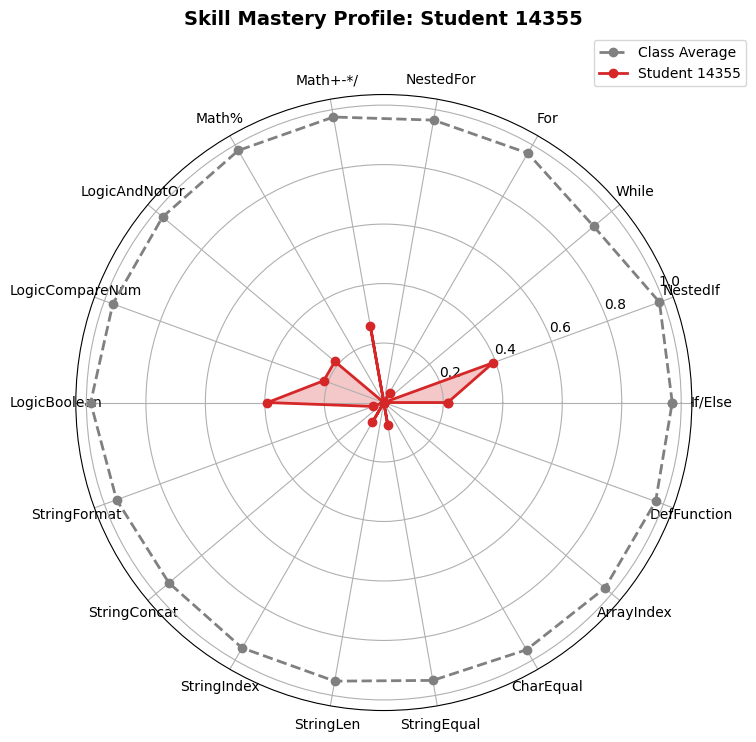


--- 🚨 Verified Skill Gaps for 14355 ---
🔴 For            :   3.8% (Class Avg: 96.8%) -> Gap: -93.0%
🔴 StringFormat   :   3.8% (Class Avg: 95.6%) -> Gap: -91.8%
🔴 StringIndex    :   7.7% (Class Avg: 95.3%) -> Gap: -87.6%
🔴 StringEqual    :   7.7% (Class Avg: 94.9%) -> Gap: -87.2%
🔴 If/Else        :  21.5% (Class Avg: 97.0%) -> Gap: -75.5%
🔴 LogicAndNotOr  :  21.5% (Class Avg: 97.1%) -> Gap: -75.6%
🔴 LogicCompareNum:  21.5% (Class Avg: 97.0%) -> Gap: -75.5%
🔴 Math+-*/       :  26.1% (Class Avg: 97.5%) -> Gap: -71.4%
🔴 NestedIf       :  39.1% (Class Avg: 98.6%) -> Gap: -59.5%
🔴 LogicBoolean   :  39.1% (Class Avg: 98.6%) -> Gap: -59.5%


In [32]:
# 5. Student Skill Modeling & Visualization
import matplotlib.pyplot as plt
import numpy as np

def load_skill_map():
    """Loads the problem_prompts.csv to map ProblemID to Skills."""
    prompts_path = "dataset/CodeWorkout/Problem_Prompts/problem_prompts.csv"
    try:
        skill_df = pd.read_csv(prompts_path)
        # Identify skill columns (columns after 'Requirement' that are boolean/binary)
        # Based on your CSV structure: properties start from 4th column
        skill_cols = skill_df.columns[3:]
        
        # Melt or organize into a lookup dict: ProblemID -> [List of Skills]
        skill_map = {}
        for _, row in skill_df.iterrows():
            prob_id = row['ProblemID']
            required_skills = [skill for skill in skill_cols if row[skill] == 1.0]
            skill_map[prob_id] = required_skills
            
        return skill_map, list(skill_cols)
    except Exception as e:
        print(f"Error loading skill map: {e}")
        return {}, []

def calculate_student_profile(student_id, attempts_df, skill_map, all_skills):
    """
    Calculates a mastery score (0.0 - 1.0) for each skill based on problem scores.
    """
    student_work = attempts_df[attempts_df['SubjectID'] == student_id]
    
    skill_scores = {skill: [] for skill in all_skills}
    
    for _, row in student_work.iterrows():
        prob_id = row['ProblemID']
        score = row['Score']
        
        # Get skills for this problem
        if prob_id in skill_map:
            for skill in skill_map[prob_id]:
                skill_scores[skill].append(score)
    
    # Average the scores for each skill
    profile = {}
    for skill, scores in skill_scores.items():
        if scores:
            profile[skill] = sum(scores) / len(scores)
        else:
            profile[skill] = 0.0 # Or None if you want to distinguish "no attempt"
            
    return profile

# Load Data
skill_map, all_skills = load_skill_map()

# 1. Calculate Profile for Target Student (14355)
target_profile = calculate_student_profile(
    TARGET_STUDENT_ID, 
    best_attempts_df, 
    skill_map, 
    all_skills
)

# 2. Calculate Class Average Profile
# We'll take a sample of all attempts to estimate 'Average Mastery'
class_profile = {skill: [] for skill in all_skills}
for pid, skills in skill_map.items():
    # Find all attempts for this problem across class
    prob_attempts = best_attempts_df[best_attempts_df['ProblemID'] == pid]
    if not prob_attempts.empty:
        avg_score = prob_attempts['Score'].mean()
        for skill in skills:
            class_profile[skill].append(avg_score)

avg_profile_final = {k: (sum(v)/len(v) if v else 0) for k, v in class_profile.items()}

# --- Visualization: Radar Chart ---
def plot_radar_chart(student_profile, avg_profile, skills, student_id=None):
    # Use dynamic ID if provided, else fall back to global target
    display_id = student_id if student_id is not None else TARGET_STUDENT_ID

    # Filter out skills with 0 data involved to keep chart clean
    active_skills = [s for s in skills if student_profile.get(s, 0) > 0 or avg_profile.get(s, 0) > 0]
    
    if not active_skills:
        print("No skill data available to plot.")
        return

    # Data Prep
    labels = np.array(active_skills)
    stats_student = np.array([student_profile.get(s, 0) for s in active_skills])
    stats_avg = np.array([avg_profile.get(s, 0) for s in active_skills])

    # Close the loop for radar chart
    stats_student = np.concatenate((stats_student, [stats_student[0]]))
    stats_avg = np.concatenate((stats_avg, [stats_avg[0]]))
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Draw Class Average
    ax.plot(angles, stats_avg, 'o-', linewidth=2, linestyle='dashed', color='gray', label='Class Average')
    
    # Draw Student
    ax.plot(angles, stats_student, 'o-', linewidth=2, color='#d62728', label=f'Student {display_id}')
    ax.fill(angles, stats_student, alpha=0.25, color='#d62728')
    
    # Labels and Formatting
    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_title(f"Skill Mastery Profile: Student {display_id}", y=1.1, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    ax.grid(True)
    
    plt.show()

print("\nGenerating Skill Model Radar Chart...")
plot_radar_chart(target_profile, avg_profile_final, all_skills, student_id=TARGET_STUDENT_ID)

# Print Text Summary of Weakest Skills
print(f"\n--- 🚨 Verified Skill Gaps for {TARGET_STUDENT_ID} ---")
sorted_skills = sorted(target_profile.items(), key=lambda x: x[1])
for skill, score in sorted_skills:
    if score < 0.6 and score > 0.0: # Filter for attempted but failed
        class_avg = avg_profile_final.get(skill, 0)
        gap = class_avg - score
        print(f"🔴 {skill:<15}: {score*100:5.1f}% (Class Avg: {class_avg*100:.1f}%) -> Gap: -{gap*100:.1f}%")

In [27]:
# Run Visualizer on Experiment 1 Results (Single Assignment)
print("--- Manual Validation: Experiment 1 (Single Assignment) ---")
if 'single_df' in locals() and not single_df.empty:
    for idx, row in single_df.iterrows():
        visualize_assessment(row)
        print("="*80 + "\n")
else:
    print("Please run Experiment 1 first to generate results.")

--- Manual Validation: Experiment 1 (Single Assignment) ---
Please run Experiment 1 first to generate results.


In [15]:
# Run Visualizer on Experiment 2 Results (Batch Analysis)
print("--- Manual Validation: Experiment 2 (Batch Analysis) ---")
if 'exp2_df' in locals() and not exp2_df.empty:
    for idx, row in exp2_df.iterrows():
        visualize_assessment(row)
        print("="*80 + "\n")
else:
    print("Please run Experiment 2 first to generate results.")

--- Manual Validation: Experiment 2 (Batch Analysis) ---


### 🔍 Validation: Problem 24 (Score: 0.0)
#### 🧑‍🎓 Student Code:
```java
public int blackjack(int a, int b)
{
    if ( a < 21 && b < a)
    {
        System.out.println(a);
    }
    else if ( a > 21 && b > 21)
    {
        System.out.println(0);
    }
    else if ( b < 21 && b > a)
    {
        System.out.println(b);
    }
    else
    {
        
    }
}

```
---
#### 🤖 LLM Assessments:
#### **Zero-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Understanding of method return types: The student declared the method `blackjack` to return an `int`, but instead of using the `return` keyword, they used `System.out.println()` to display values. This indicates a fundamental misunderstanding of how methods communicate results back to the caller versus how they produce output to the console.
- 🔴 Completeness of conditional logic: The `if-else if` conditions are incomplete and do not cover all possible scenarios required by the blackjack problem (e.g., one number busts and the other doesn't, or correctly identifying which valid number is closer to 21). The logic also doesn't account for cases where both numbers are valid and equal.
- 🔴 Handling of all code paths for non-void methods: The method has an `else` block that is empty and does not contain a `return` statement. This means there are execution paths through the method where no value is returned, which is a compile-time error for methods declared with a non-void return type.

**Future Predictions:**
- 🔮 Struggling with method design and implementation, particularly when methods need to compute and return a specific value rather than just performing an action or printing output.
- 🔮 Difficulty in designing robust conditional logic for more complex problems, leading to incomplete solutions or incorrect handling of edge cases.
- 🔮 Challenges in debugging and interpreting compiler errors related to missing return statements or type mismatches, as they seem to confuse output with return values.
- 🔮 Struggling with algorithm design, especially for problems requiring careful consideration of multiple conditions and their precedence to arrive at a correct result.

---
#### **Few-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Method signature and return values: The method is declared to return 'int' but contains no 'return' statements, only 'System.out.println()'. This indicates a fundamental misunderstanding of how methods communicate results back to the caller.
- 🔴 Comprehensive conditional logic: The 'if-else if' structure does not cover all possible scenarios for the blackjack problem (e.g., what if only one number is over 21, or if both are under 21 but equal, or if one is exactly 21). The conditions are not mutually exclusive and exhaustive.
- 🔴 Problem interpretation/Algorithm design: The student's chosen conditions (e.g., 'b < a' in the first 'if') suggest a misunderstanding of the specific rules for determining the 'best' blackjack hand (closest to 21 without exceeding).

**Future Predictions:**
- 🔮 Implementing methods with non-void return types: Will continue to struggle with methods that are expected to compute and return a value, potentially using 'System.out.println()' instead of 'return'.
- 🔮 Handling edge cases in conditional logic: Will frequently miss specific scenarios or edge cases when writing 'if-else if-else' statements, leading to incomplete or incorrect behavior.
- 🔮 Debugging logical flow: Will have difficulty tracing the execution path through complex conditional statements and identifying why certain inputs lead to unexpected outputs or no output at all.
- 🔮 Designing algorithms for multi-case problems: Will struggle with problems that require breaking down a complex task into multiple distinct scenarios and handling each appropriately.

---
#### **Chain-of-Thought Strategy**
**Knowledge Gaps:**
- 🔴 Method Return Types
- 🔴 Comprehensive Conditional Logic (If-Else If-Else)
- 🔴 Distinction between Printing and Returning Values

**Future Predictions:**
- 🔮 Method Design and API Usage
- 🔮 Debugging and Program Flow
- 🔮 Complex Conditional Logic and Algorithm Implementation
- 🔮 Object-Oriented Programming (OOP)

**🧠 Reasoning Chain:**
- **step1_behavior**: The `blackjack` method takes two integers, `a` and `b`. It contains a series of `if-else if` statements. The first condition checks if `a` is less than 21 AND `b` is less than `a`. If true, it prints `a` to the console. The second condition checks if both `a` and `b` are greater than 21. If true, it prints `0` to the console. The third condition checks if `b` is less than 21 AND `b` is greater than `a`. If true, it prints `b` to the console. If none of these conditions are met, the `else` block is executed, which contains no statements. Crucially, the method is declared to return an `int` but contains no `return` statements in any execution path.
- **step2_failures**: 1.  **Compile-time error: Missing return statement.** The method signature `public int blackjack(int a, int b)` indicates it must return an integer, but no `return` statement is present in the code. This will prevent the code from compiling. 
2.  **Incorrect problem logic.** The conditions do not correctly implement the simplified blackjack rules. For example:
    *   It doesn't handle cases where one number is over 21 and the other is not (e.g., `a=22, b=10` would fall into the empty `else` block). The expected behavior would be to return 10.
    *   It doesn't correctly compare `a` and `b` when both are under 21 but `a` is greater than `b` (e.g., `a=19, b=15` would print `a`, but the logic is incomplete for other valid scenarios).
    *   It doesn't handle cases where one or both numbers are exactly 21.
    *   The conditions `b < a` and `b > a` are too restrictive and don't cover all scenarios for comparing `a` and `b` when both are valid.
3.  **Misunderstanding `return` vs. `System.out.println`.** The student uses `System.out.println` to display values, whereas the problem requires the method to `return` an integer value to the caller.
- **step3_missing_concepts**: 1.  **Method Return Types:** The student does not understand that a method declared with a non-void return type (like `int`) *must* include a `return` statement that provides a value of that type in all possible execution paths. 
2.  **Conditional Logic and Comprehensive Case Handling:** The student struggles with designing a robust `if-else if-else` structure that covers all possible input scenarios and correctly applies the problem's rules. The conditions are incomplete and not ordered effectively to handle edge cases or prioritize certain conditions (like busting).
3.  **Distinction between Output and Return Values:** The student confuses printing a value to the console (`System.out.println`) with returning a value from a method, which is how a method communicates its result back to the code that called it.
- **step4_future_impact**: 1.  **Method Design and API Usage:** Without a clear understanding of return types, the student will struggle to design methods that correctly provide results to other parts of a program or to use library methods that expect return values. 
2.  **Debugging and Program Flow:** Misunderstanding how `return` statements work will make it difficult to trace program execution, especially in methods that call other methods, leading to confusion about why programs behave a certain way. 
3.  **Complex Conditional Logic and Algorithm Implementation:** The current struggle with comprehensive `if-else if` structures will make it difficult to implement more complex decision-making processes and algorithms in future assignments, as they often rely on carefully constructed conditional logic. 
4.  **Object-Oriented Programming (OOP):** A poor grasp of method design, including return types and how methods interact, will hinder understanding and implementing OOP principles, as methods are fundamental to defining object behavior.

---
#### **Curriculum-Aware Strategy**
**Knowledge Gaps:**
- 🔴 Misunderstanding of method return types and the 'return' keyword. The method is declared to return an 'int', but the student uses 'System.out.println()' instead of 'return' to provide a value. Additionally, not all execution paths return a value, leading to a compilation error.
- 🔴 Incomplete and incorrect conditional logic for the problem's requirements. The `if-else if` structure does not correctly identify the value nearest to 21 without going over, nor does it handle all possible scenarios (e.g., when one value is over 21 and the other is not, or when both are under 21 and a comparison for 'nearest' is needed).

**Future Predictions:**
- 🔮 **Method**: A fundamental misunderstanding of how methods return values will cause compilation errors and incorrect program behavior in almost all non-void methods. This is a core concept for modularizing code.
- 🔮 **Logic**: The student struggles with designing conditional statements that correctly cover all problem scenarios and edge cases. This will lead to incorrect solutions for problems requiring complex decision-making, such as those involving multiple conditions or nested logic.
- 🔮 **Condition**: The student's current conditions do not accurately reflect the problem's requirements (e.g., 'nearest to 21 without going over'). This indicates difficulty in translating natural language problem statements into precise boolean expressions.

**🎓 Intervention:**
> Review the concept of methods, specifically focusing on return types and the use of the `return` keyword. Provide exercises that explicitly differentiate between printing a value and returning a value. Work through simpler conditional logic problems, breaking down requirements into distinct `if-else if-else` branches, and then revisit this problem to apply the learned concepts.

---


### 🔍 Validation: Problem 232 (Score: 0.0)
#### 🧑‍🎓 Student Code:
```java
public String alarmClock(int day, boolean vacation)
{
   if (alarmClock(0, !vacation))
   {
       return("10:00");
   }
   else if (alarmClock(1, !vacation))
   {
       return("7:00");
   }
}

```
---
#### 🤖 LLM Assessments:
#### **Zero-Shot Strategy**
**Knowledge Gaps:**
- 🔴 **Recursion Fundamentals**: The student attempts to use recursion without a proper understanding of base cases or how recursive calls should contribute to the solution. The recursive calls `alarmClock(0, !vacation)` and `alarmClock(1, !vacation)` are not designed to terminate or solve the problem, leading to infinite recursion.
- 🔴 **Method Signature and Return Type Mismatch**: The `alarmClock` method is declared to return a `String`, but the student attempts to use its return value as a `boolean` in the `if` and `else if` conditions (e.g., `if (alarmClock(0, !vacation))`). Java does not allow implicit conversion from `String` to `boolean`, causing a compile-time error.
- 🔴 **Conditional Logic Application**: The student misunderstands how to use `if` and `else if` statements. Instead of checking the current `day` and `vacation` parameters, they are making new, unrelated method calls within the conditions.
- 🔴 **Missing Return Statement**: There is no `return` statement for all possible code paths. If the initial `if` and `else if` conditions (which are fundamentally flawed) were somehow bypassed, the method would not return a value, leading to a compile-time error.
- 🔴 **Basic Compilation Errors**: The code contains fundamental type mismatches and missing return statements that prevent it from compiling, indicating a struggle with understanding basic Java syntax and compiler feedback.

**Future Predictions:**
- 🔮 **Debugging and Error Resolution**: Will struggle significantly with identifying and resolving both compile-time errors (like type mismatches and missing returns) and runtime errors (like `StackOverflowError` due to infinite recursion).
- 🔮 **Method Design and Implementation**: Will have difficulty designing methods with correct parameters, return types, and internal logic that accurately reflect problem requirements.
- 🔮 **Control Flow and Conditional Logic**: Will struggle with more complex conditional statements, loops, and understanding how program execution flows through different branches of code.
- 🔮 **Understanding Type Systems**: Will likely continue to struggle with Java's strong type system, leading to issues with variable assignments, method arguments, and return values.
- 🔮 **Algorithm Design**: Will find it challenging to translate problem descriptions into a step-by-step executable solution, especially when it involves decision-making or iterative processes.

---
#### **Few-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Incorrect use of recursion (missing base case, leading to infinite recursion)
- 🔴 Type mismatch: Attempting to use a String return value as a boolean condition in an 'if' statement
- 🔴 Missing return statement for all possible execution paths in a method declared to return a value
- 🔴 Fundamental misunderstanding of how to use method parameters to determine the current method's output

**Future Predictions:**
- 🔮 Debugging 'StackOverflowError'
- 🔮 Resolving compile-time errors related to type incompatibility
- 🔮 Implementing correct conditional logic ('if/else if/else') based on multiple input parameters
- 🔮 Understanding the flow of control and parameter usage in methods

---
#### **Chain-of-Thought Strategy**
**Knowledge Gaps:**
- 🔴 Recursion (specifically, the need for base cases)
- 🔴 Method return types and type compatibility in conditional expressions
- 🔴 Correct use of if/else if statements for conditional logic based on input parameters
- 🔴 Understanding the purpose and usage of method parameters

**Future Predictions:**
- 🔮 Problems involving recursion
- 🔮 Debugging type errors and StackOverflowError
- 🔮 Implementing any non-trivial conditional logic
- 🔮 Understanding method contracts and API usage
- 🔮 Algorithm design and problem decomposition

**🧠 Reasoning Chain:**
- **step1_behavior**: The `alarmClock` method is called with an integer `day` and a boolean `vacation`. Inside the method, there's an `if` statement that recursively calls `alarmClock(0, !vacation)`. If this recursive call somehow evaluates to `true` (which it cannot, as `alarmClock` returns a String), it returns the string "10:00". An `else if` statement then recursively calls `alarmClock(1, !vacation)`. If this call evaluates to `true`, it returns "7:00". The method lacks a base case for its recursive calls and also lacks a return statement for cases where neither of the `if` or `else if` conditions are met.
- **step2_failures**: 1.  **Compile-time Error (Type Mismatch):** The primary failure is that the `if` and `else if` conditions `alarmClock(0, !vacation)` and `alarmClock(1, !vacation)` are attempting to use the return value of `alarmClock` (which is `String`) as a boolean condition. Java requires a `boolean` expression for `if` conditions, leading to a compile-time error. A `String` cannot be implicitly converted to a `boolean`. 
2.  **Compile-time Error (Missing Return Statement):** If the type mismatch were somehow resolved, the method would still fail to compile because there is no `return` statement outside the `if`/`else if` blocks. A method declared to return `String` must guarantee a `String` is returned on all possible execution paths. 
3.  **Runtime Error (Infinite Recursion):** If the type mismatch were ignored (e.g., in a language with looser typing or if the student intended `alarmClock` to return `boolean`), the code would result in an infinite recursion. There are no base cases to stop the recursive calls `alarmClock(0, !vacation)` and `alarmClock(1, !vacation)`, leading to a `StackOverflowError` at runtime. 
4.  **Incorrect Logic:** The method completely ignores its input parameters `day` and `vacation` in its primary logic flow, instead using hardcoded values (0 and 1 for `day`, and `!vacation` for `vacation`) in recursive calls. This means the method would never produce the correct alarm time based on the actual inputs.
- **step3_missing_concepts**: 1.  **Recursion Base Cases:** The student does not understand that recursive functions require a base case to terminate the recursion and prevent infinite loops. 
2.  **Method Return Types and Type Compatibility:** The student is attempting to use a `String` return value as a `boolean` condition in an `if` statement, indicating a fundamental misunderstanding of Java's type system and how method return values are used. 
3.  **Conditional Logic (if/else if/else):** The student is not using the input parameters (`day`, `vacation`) to drive the conditional logic. Instead, they are using recursive calls with hardcoded values, demonstrating a lack of understanding of how to use `if`/`else if` statements to make decisions based on input. 
4.  **Parameter Usage:** The student is not utilizing the method's input parameters (`day`, `vacation`) to solve the problem. They are effectively ignored in the main logic.
- **step4_future_impact**: 1.  **Recursion:** The student will struggle with any problem requiring recursion, as they lack the foundational understanding of base cases. 
2.  **Type System and Method Contracts:** The confusion between `String` and `boolean` in conditional logic suggests a weak grasp of Java's type system, which will lead to frequent compile-time errors and difficulty understanding how methods are designed to interact. 
3.  **Control Flow and Conditional Statements:** The inability to correctly use `if`/`else if` statements based on input parameters will hinder the student's ability to implement any logic requiring decision-making, which is fundamental to almost all programming tasks. 
4.  **Debugging:** The student will likely struggle to debug `StackOverflowError` and type mismatch errors without a clearer understanding of these concepts. 
5.  **Algorithm Design:** The student is not effectively using input parameters to design a solution, which will impact their ability to design algorithms for even moderately complex problems.

---
#### **Curriculum-Aware Strategy**
**Knowledge Gaps:**
- 🔴 Misunderstanding of conditional statements and boolean expressions: The student attempts to use recursive method calls (which return String) directly as boolean conditions in 'if' statements, leading to a type mismatch compilation error.
- 🔴 Incorrect application and understanding of recursion: The student uses recursive calls within the 'if' conditions without a clear base case or proper parameter modification, which would lead to infinite recursion if it compiled. This problem is not intended to be solved recursively.
- 🔴 Incomplete method implementation and missing return statement: The method is declared to return a String, but there are paths where no String is returned (e.g., if neither 'if' nor 'else if' condition is met, or if the conditions were valid but didn't cover all cases).
- 🔴 Lack of problem decomposition and direct parameter evaluation: The student does not use the input parameters 'day' and 'vacation' directly in their conditional logic to determine the alarm time. Instead, they try to use fixed values (0, 1) and an inverted 'vacation' in recursive calls.

**Future Predictions:**
- 🔮 **Condition**: The student fundamentally misunderstands how to construct and use boolean expressions in 'if' statements, which is a core concept for all conditional logic. This will impact any problem requiring decision-making.
- 🔮 **Logic**: The student's approach shows a significant gap in translating problem requirements into executable code logic, particularly in handling multiple conditions and mapping input parameters to outputs.
- 🔮 **Method**: The misuse of recursion and confusion about return types in conditions indicates a weak grasp of method invocation, parameter passing, and the role of return values. This will hinder understanding of method design and interaction.
- 🔮 **Loop**: Since loop continuation conditions are essentially boolean expressions, the student's struggle with 'if' conditions will directly translate to difficulties in designing and implementing correct loop conditions.

**🎓 Intervention:**
> Immediate review of Chapter 3 (Selections), focusing on the structure of 'if-else' statements, how to form boolean expressions using comparison and logical operators, and the concept of method return types. Provide simpler problems that require direct conditional checks on input parameters. Explicitly discuss common compilation errors related to type mismatches in 'if' conditions and missing return statements.

---


### 🔍 Validation: Problem 40 (Score: 0.0769231)
#### 🧑‍🎓 Student Code:
```java
public String getSandwich(String str)
{
    return str;
}

```
---
#### 🤖 LLM Assessments:
#### **Zero-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Lack of understanding of problem requirements and how to translate them into executable code.
- 🔴 Absence of basic string manipulation techniques (e.g., `indexOf`, `substring`, `length`) which are fundamental for this type of problem.
- 🔴 Inability to formulate a basic algorithm or logical steps to solve a given programming challenge.
- 🔴 Limited understanding of how to approach and solve programming problems beyond simply returning the input parameter.

**Future Predictions:**
- 🔮 Struggling with any problem requiring string processing, parsing, or pattern matching.
- 🔮 Difficulty with problems that require conditional logic (`if`/`else` statements) or iterative structures (`for`/`while` loops) to implement specific logic.
- 🔮 Challenges in designing and implementing algorithms for even moderately complex problems.
- 🔮 Struggling with debugging and testing their own code effectively, as evidenced by the low score and lack of problem-solving attempt.

---
#### **Few-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Problem understanding/decomposition
- 🔴 Basic string manipulation (e.g., indexOf, substring, length)
- 🔴 Conditional logic

**Future Predictions:**
- 🔮 String methods (indexOf, lastIndexOf, substring)
- 🔮 Looping and iteration over strings
- 🔮 Conditional statements and boolean logic
- 🔮 Algorithm design for string problems

---
#### **Chain-of-Thought Strategy**
**Knowledge Gaps:**
- 🔴 String methods for searching (indexOf, lastIndexOf)
- 🔴 String methods for extraction (substring)
- 🔴 Conditional logic for handling different string states
- 🔴 Basic algorithm design for string processing

**Future Predictions:**
- 🔮 Parsing structured data (e.g., CSV, JSON strings)
- 🔮 Implementing search algorithms on sequences
- 🔮 Developing robust error handling for input validation
- 🔮 Working with character arrays or StringBuilder/StringBuffer

**🧠 Reasoning Chain:**
- **step1_behavior**: The student's code defines a method `getSandwich` that accepts a single String argument `str`. The method's body consists of a single line: `return str;`. This means the method simply returns the input string exactly as it was received, without performing any modifications, searches, or extractions.
- **step2_failures**: The problem name `getSandwich` strongly implies that the method should find and return the substring between the first and last occurrences of the word 'bread' in the input string. The current code fails to do this because it does not implement any logic for string searching (e.g., finding 'bread'), substring extraction, or handling edge cases (e.g., 'bread' not found, only one 'bread', no content between 'breads'). For example, if the input is 'breadjambread', the expected output is 'jam', but the code returns 'breadjambread'. If the input is 'xxbreadjambreadyy', it returns 'xxbreadjambreadyy' instead of 'jam'. If the input is 'breadbread', it returns 'breadbread' instead of an empty string.
- **step3_missing_concepts**: 1.  **String Manipulation Methods:** The student does not demonstrate knowledge of fundamental Java String methods like `indexOf()`, `lastIndexOf()`, or `substring()` which are essential for locating and extracting parts of a string. 
2.  **Conditional Logic:** The problem implicitly requires checking for the presence of 'bread' and handling different scenarios (e.g., if 'bread' isn't found, if there's only one, if there are multiple). The student has not implemented any `if/else` statements or other conditional logic to address these cases.
3.  **Algorithmic Thinking / Problem Decomposition:** The student has not broken down the problem into smaller, manageable steps (e.g., find first delimiter, find second delimiter, extract content, handle edge cases). The submission suggests a lack of understanding in how to approach and solve a string-based algorithmic problem.
- **step4_future_impact**: 1.  **Advanced String Processing:** The student will struggle with any future problems requiring parsing, tokenizing, or extracting specific patterns from strings (e.g., parsing CSV data, URL parameters, simple command-line arguments).
2.  **Data Structure Traversal and Manipulation:** A lack of understanding in manipulating elements within a string (a sequence of characters) will likely translate to difficulties in traversing and manipulating elements within other sequential data structures like arrays or lists.
3.  **Robust Error Handling/Edge Case Management:** The inability to consider and handle different input scenarios (like 'bread' not being present) indicates a future struggle with writing robust code that accounts for edge cases and invalid inputs.
4.  **Regular Expressions:** Understanding how to use `indexOf` and `substring` is a prerequisite for understanding more powerful text processing tools like regular expressions.

---
#### **Curriculum-Aware Strategy**
**Knowledge Gaps:**
- 🔴 Complete lack of problem-solving attempt. The student's code simply returns the input string without any logic or manipulation, indicating a fundamental misunderstanding of how to approach the problem.
- 🔴 No use of String class methods (e.g., indexOf, substring, length) which are essential for this problem.
- 🔴 Absence of conditional logic (if statements) to handle different cases, such as checking for the presence of 'bread' or returning an empty string.

**Future Predictions:**
- 🔮 **String**: The student has not demonstrated any ability to use basic String methods for searching, extracting, or manipulating text, which are core to Chapter 9. They will struggle with any problem requiring string parsing.
- 🔮 **Logic**: The complete absence of problem-solving logic suggests a significant gap in translating a problem description into a sequence of computational steps and conditional checks. This will impact all future programming tasks.
- 🔮 **Method**: While the method signature is syntactically correct, the student has not demonstrated understanding of how to implement the body of a method to perform a specific task, beyond a trivial return statement.
- 🔮 **Condition**: Without understanding how to use 'if' statements, the student will be unable to implement any decision-making logic, which is fundamental to almost all programming problems.

**🎓 Intervention:**
> This student needs immediate and significant intervention. A one-on-one session is highly recommended to review fundamental concepts: how to read a problem, break it down, identify necessary Java features (like String methods and if statements), and then translate those into code. Start with simpler problems involving basic string operations and conditional logic before returning to this problem.

---


### 🔍 Validation: Problem 13 (Score: 0.782609)
#### 🧑‍🎓 Student Code:
```java
public int caughtSpeeding(int speed, boolean isBirthday)
{
    if (isBirthday)
    {
        speed = speed + 5;
        if (speed <= 60)
        {
            return(0);
        }
        else if (speed >= 61 && speed <= 80)
        {
            return(1);
        }
        else
        {
            return(2);
        }
    }
    else
    {
        speed = speed;
        if (speed <= 60)
        {
            return(0);
        }
        else if (speed >= 61 && speed <= 80)
        {
            return(1);
        }
        else
        {
            return(2);
        }
    }

}

```
---
#### 🤖 LLM Assessments:
#### **Zero-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Misinterpretation of problem requirements: The student incorrectly applied the 'birthday' rule. Instead of effectively increasing the speed thresholds (or decreasing the driver's speed for comparison), they increased the driver's speed, which has the opposite effect of making them more likely to get a ticket on their birthday.
- 🔴 Redundant code: The line `speed = speed;` in the `else` block is unnecessary and performs no operation. While harmless, it indicates a lack of understanding of basic assignment or an oversight in code efficiency.
- 🔴 Insufficient test case verification: The student likely did not thoroughly test their code with various inputs, especially those involving the `isBirthday` condition, which would have revealed the incorrect logic for birthday scenarios.

**Future Predictions:**
- 🔮 Struggling with complex conditional logic: Problems requiring nuanced interpretation of rules and precise application of conditional adjustments will be challenging.
- 🔮 Difficulty in debugging and test-driven development: Without a systematic approach to verifying code against expected outputs, identifying and fixing errors will remain a struggle.
- 🔮 Inefficient code and refactoring: The presence of redundant code suggests a potential lack of focus on writing clean, concise, and efficient code, which will hinder refactoring efforts.
- 🔮 Understanding the impact of variable modifications: Misunderstanding how changes to a variable (like `speed` in this case) affect subsequent comparisons and logic can lead to errors in more complex programs.

---
#### **Few-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Logical error in applying conditional rules: The 'birthday bonus' is incorrectly applied by increasing the speed instead of adjusting the speed limits or using a reduced speed for comparison. This demonstrates a misunderstanding of how to translate a problem's rule (e.g., '5 mph grace') into code.
- 🔴 Redundant code: The line 'speed = speed;' in the 'else' block is unnecessary and indicates a lack of awareness regarding variable assignment and code efficiency.

**Future Predictions:**
- 🔮 Translating complex word problems into code, especially those involving multiple conditions or adjustments to rules.
- 🔮 Code efficiency and refactoring, as evidenced by the duplicated 'if-else if-else' structure instead of calculating an adjusted speed once.
- 🔮 Debugging logical errors, as the code compiles but produces incorrect results due to a flaw in the problem's interpretation.

---
#### **Chain-of-Thought Strategy**
**Knowledge Gaps:**
- 🔴 Conditional Logic / Problem Decomposition
- 🔴 Redundant Code / Variable Assignment

**Future Predictions:**
- 🔮 Complex Conditional Logic
- 🔮 Debugging Logical Errors
- 🔮 Algorithm Design
- 🔮 Code Optimization and Readability

**🧠 Reasoning Chain:**
- **step1_behavior**: The student's code defines a method `caughtSpeeding` that takes an integer `speed` and a boolean `isBirthday`. It first checks if `isBirthday` is true. If it is, the code increases the `speed` variable by 5. Then, it proceeds to check the (potentially adjusted) `speed` against three ranges: `speed <= 60` (returns 0), `speed >= 61 && speed <= 80` (returns 1), and `speed > 80` (returns 2). If `isBirthday` is false, the code executes `speed = speed;` (which has no effect) and then checks the original `speed` against the same three ranges: `speed <= 60` (returns 0), `speed >= 61 && speed <= 80` (returns 1), and `speed > 80` (returns 2).
- **step2_failures**: The code fails in the `isBirthday` case. The problem typically implies that on a birthday, the speed limits for tickets are increased by 5 (e.g., no ticket up to 65, small ticket up to 85). The student's code, however, adds 5 to the `speed` variable itself and then applies the *standard* speed limits (60, 80). This has the effect of making the original speed limits effectively *lower* for the birthday person, which is incorrect. For example, if the actual speed is 60 on a birthday, the code calculates `speed = 60 + 5 = 65`. Then it checks `65 <= 60` (false), `65 >= 61 && 65 <= 80` (true), and returns 1. The expected behavior for a speed of 60 on a birthday (with limits shifted by 5) should be `60 <= (60+5)` or `60 <= 65`, which should result in 0 (no ticket). The line `speed = speed;` in the `else` block is redundant and serves no purpose, though it doesn't cause a functional error.
- **step3_missing_concepts**: 1.  **Conditional Logic / Problem Decomposition:** The student understands how to use `if-else` statements but struggles with how to correctly implement a conditional modification to the problem's logic. Instead of shifting the *thresholds* or having separate comparison logic for the birthday case, they incorrectly modify the input variable in a way that misaligns with the desired outcome of the problem statement. They understand that `isBirthday` matters, but not *how* to correctly translate the requirement into code that modifies the comparison criteria. 
2.  **Redundant Code / Variable Assignment:** The inclusion of `speed = speed;` suggests a minor misunderstanding of variable assignment or a lack of attention to writing concise and meaningful code.
- **step4_future_impact**: 1.  **Complex Conditional Logic:** The student will likely struggle with problems requiring more intricate conditional logic, especially when conditions affect the interpretation or application of other rules or values. 
2.  **Debugging Logical Errors:** This type of error (code runs but produces incorrect output) is a logical error. The student may find it difficult to trace execution and identify the source of such discrepancies in more complex programs. 
3.  **Algorithm Design:** Translating nuanced problem requirements into a correct algorithmic structure will be challenging if they continue to misinterpret how conditions should modify the core logic. 
4.  **Code Optimization and Readability:** The redundant line suggests they might not prioritize or understand the importance of writing clean, efficient, and easily understandable code.

---
#### **Curriculum-Aware Strategy**
**Knowledge Gaps:**
- 🔴 Misinterpretation of conditional logic in problem statement. The student incorrectly applied the '5 higher' rule by increasing the driver's speed variable, which makes it harder for the driver to avoid a ticket. The problem intended for the speed *thresholds* to be 5 higher, granting leniency.
- 🔴 Included a redundant self-assignment statement that has no effect on the program's execution.

**Future Predictions:**
- 🔮 **Logic**: The student struggled with accurately translating a conditional rule from a problem description into correct code logic. They may continue to misinterpret problem requirements involving adjustments, exceptions, or multiple interacting conditions, leading to incorrect transformations or comparisons.
- 🔮 **Condition**: Similar issues are likely to arise in problems requiring complex if-else structures where conditions or thresholds need to be dynamically adjusted based on other factors, as the student demonstrated difficulty in applying such adjustments correctly.

**🎓 Intervention:**
> Encourage the student to carefully re-read problem statements, especially phrases describing conditional modifications or exceptions. Suggest drawing out 'what if' scenarios and manually tracing code execution with various inputs (including edge cases) to verify that the code's logic matches the problem's intent. Discuss the difference between modifying an input value versus modifying the criteria (thresholds) against which the input value is compared. Also, point out and explain why redundant code like 'speed = speed;' is unnecessary.

---


### 🔍 Validation: Problem 41 (Score: 0.0)
#### 🧑‍🎓 Student Code:
```java
public int sum3(int[] nums)
{
   return int[1 + 2 + 0];
}

```
---
#### 🤖 LLM Assessments:
#### **Zero-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Basic Java syntax for array element access (e.g., `arrayName[index]`). The student attempted to use `int[index]` which is incorrect syntax for accessing an array element and instead resembles an array type declaration.
- 🔴 Understanding of return statement syntax and type compatibility. The method is declared to return an `int`, but the student attempted to return an array type declaration (`int[3]`) which is not an integer value.
- 🔴 Fundamental understanding of how to perform arithmetic operations on array elements. The student did not attempt to access or sum any elements from the input `nums` array.
- 🔴 Distinction between declaring an array type (e.g., `int[]`) and accessing an element within an array instance (e.g., `nums[0]`).

**Future Predictions:**
- 🔮 Struggling with any problem involving array manipulation, iteration over arrays, or accessing specific elements.
- 🔮 Difficulty with more complex data structures (e.g., lists, maps, custom objects) that rely on correct element access and manipulation.
- 🔮 Challenges in understanding and implementing algorithms that require data processing, as basic data access is a prerequisite.
- 🔮 Struggling with debugging type mismatch errors and syntax errors, as the current code demonstrates a lack of understanding of fundamental Java syntax and type rules.

---
#### **Few-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Incorrect syntax for returning a value (attempting to return 'int[expression]' instead of an integer value)
- 🔴 Lack of understanding of how to access elements within an array (e.g., nums[0])
- 🔴 Confusion between array type (int[]) and primitive integer type (int)

**Future Predictions:**
- 🔮 Array indexing and traversal
- 🔮 Basic method return types and values
- 🔮 Fundamental Java syntax for expressions and statements

---
#### **Chain-of-Thought Strategy**
**Knowledge Gaps:**
- 🔴 Array Element Access
- 🔴 Return Statement Syntax
- 🔴 Basic Arithmetic Operations on Array Elements

**Future Predictions:**
- 🔮 Iterating over collections (loops)
- 🔮 Implementing algorithms on data structures
- 🔮 Understanding object references vs. values
- 🔮 Debugging compilation errors

**🧠 Reasoning Chain:**
- **step1_behavior**: The student's code defines a method `sum3` that is intended to return an integer. Inside the method, it attempts to return `int[1 + 2 + 0];`. The expression `1 + 2 + 0` evaluates to `3`. Therefore, the code tries to return `int[3];`.
- **step2_failures**: The code fails immediately due to a compilation error. `int[3]` is not a valid expression that evaluates to an integer value; it's syntactically incorrect for a return statement expecting an `int`. It looks like an attempt to declare an array type or size, not to return a value. Even if it were syntactically valid, it does not access any elements of the `nums` array, nor does it perform any summation of its contents, which is the likely intent of a method named `sum3` that takes an array.
- **step3_missing_concepts**: ['**Array Element Access:** The student does not understand how to access individual elements within an array using an index (e.g., `nums[0]`, `nums[1]`). They are attempting to use array-like syntax but not for accessing elements.', '**Return Statement Syntax:** The student misunderstands the correct syntax for returning a primitive integer value from a method. `return int[expression];` is not valid Java syntax for returning an `int` value.', '**Basic Arithmetic Operations on Array Elements:** The core task of summing array elements is not attempted, which stems from the inability to access the elements themselves.']
- **step4_future_impact**: ['**Iterating over collections (loops):** Without understanding how to access individual elements, the student will struggle significantly with any form of iteration (e.g., `for` loops, enhanced `for` loops) over arrays or other collection types.', '**Implementing algorithms on data structures:** Any algorithm that requires processing, manipulating, searching, or sorting individual elements within an array (or any data structure) will be impossible to implement.', '**Understanding object references vs. values:** The confusion between `int` (a primitive type) and `int[3]` (an array type/declaration) suggests a fundamental misunderstanding of types, values, and how they are handled in Java, which is crucial for grasping object-oriented concepts.', "**Debugging compilation errors:** The student's code doesn't even compile, indicating a lack of familiarity with basic Java syntax rules, which will make even simple programming tasks frustrating."]

---
#### **Curriculum-Aware Strategy**
**Knowledge Gaps:**
- 🔴 Misunderstanding of array element access syntax and purpose of return statement.
- 🔴 Lack of understanding of basic arithmetic operations on array elements.

**Future Predictions:**
- 🔮 **Array**: Without understanding how to access individual elements of an array, the student will be unable to perform any operations on arrays, including traversal, searching, sorting, or processing. This is a foundational concept for Chapter 6.
- 🔮 **Logic**: The student's code demonstrates a significant logical flaw in how to approach the problem of summing array elements. This indicates difficulty in translating problem requirements into executable code steps.
- 🔮 **Method**: The incorrect use of the 'return' statement suggests a misunderstanding of how value-returning methods work and what type of value they are expected to return. This will impact all future method implementations.

**🎓 Intervention:**
> Review Chapter 6, focusing on array declaration, initialization, and element access using indices. Provide hands-on practice with simple array problems, such as summing, finding the maximum/minimum, or calculating the average of array elements. Emphasize the correct syntax for accessing array elements (e.g., `nums[index]`) and the role of the `return` statement in methods.

---


In [16]:
# Run Visualizer on Experiment 3 Results (Full History)
# Limiting to first 5 for brevity
print("--- Manual Validation: Experiment 3 (Full History - Sample) ---")
if 'exp3_df' in locals() and not exp3_df.empty:
    for idx, row in exp3_df.head(5).iterrows():
        visualize_assessment(row)
        print("="*80 + "\n")
else:
    print("Please run Experiment 3 first to generate results.")

--- Manual Validation: Experiment 3 (Full History - Sample) ---


### 🔍 Validation: Problem 13 (Score: 0.782609)
#### 🧑‍🎓 Student Code:
```java
public int caughtSpeeding(int speed, boolean isBirthday)
{
    if (isBirthday)
    {
        speed = speed + 5;
        if (speed <= 60)
        {
            return(0);
        }
        else if (speed >= 61 && speed <= 80)
        {
            return(1);
        }
        else
        {
            return(2);
        }
    }
    else
    {
        speed = speed;
        if (speed <= 60)
        {
            return(0);
        }
        else if (speed >= 61 && speed <= 80)
        {
            return(1);
        }
        else
        {
            return(2);
        }
    }

}

```
---
#### 🤖 LLM Assessments:
#### **Zero-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Incorrect Application of Conditional Logic: The student misinterpreted how the 'birthday bonus' should be applied. Instead of effectively increasing the speed limits (or decreasing the effective speed for comparison), they increased the driver's speed value itself, then compared it against the *original* limits. This resulted in incorrect ticket assignments for specific speed ranges on a birthday.
- 🔴 Code Duplication and Lack of Refactoring: The core logic for determining the ticket category is repeated twice (once for `isBirthday` and once for `!isBirthday`). This indicates a missed opportunity to refactor the common logic, making the code less efficient, harder to read, and more prone to errors if changes are needed.
- 🔴 Redundant Code: The line `speed = speed;` serves no purpose and suggests a lack of understanding of basic variable assignment or an attempt to mirror a previous line without comprehending its function.

**Future Predictions:**
- 🔮 Handling Complex Conditional Requirements: Will likely struggle with problems that involve multiple interacting conditions or require dynamic adjustment of thresholds or parameters based on specific inputs.
- 🔮 Writing Maintainable and Efficient Code: Without addressing code duplication, the student will continue to produce verbose and less maintainable code, making future debugging and feature additions more challenging.
- 🔮 Debugging Logical Errors in Conditional Structures: The specific nature of the error (misapplication of a rule) suggests difficulty in mentally simulating the code's execution path and how variable modifications impact subsequent conditional checks.
- 🔮 Designing Flexible Algorithms: May struggle with designing algorithms that need to adapt their behavior or parameters based on input conditions, leading to rigid or incorrect solutions.

---
#### **Few-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Logical error in conditional modification (incorrectly applying the birthday bonus: `speed = speed + 5;` instead of `speed = speed - 5;` or adjusting thresholds).
- 🔴 Redundant code (`speed = speed;` in the else block).
- 🔴 Code duplication (the entire `if-else if-else` structure is repeated in both branches of the `isBirthday` check).

**Future Predictions:**
- 🔮 Complex conditional logic with multiple interacting variables
- 🔮 Refactoring and code optimization (identifying and eliminating redundant code)
- 🔮 Debugging and systematic testing (given 24 attempts, the student may struggle with effectively finding and fixing logical errors)
- 🔮 Precise interpretation of problem specifications

---
#### **Chain-of-Thought Strategy**
**Knowledge Gaps:**
- 🔴 Translating problem requirements (e.g., 'limits increased by X') into correct conditional expressions, specifically applying bonuses/leniency in `if/else` logic.
- 🔴 Understanding the precise effect of variable assignment and identifying redundant code.

**Future Predictions:**
- 🔮 Implementing complex business logic or game rules involving multiple, interacting conditional statements.
- 🔮 Debugging issues related to incorrect boundary conditions or misapplied logic in `if/else` structures.
- 🔮 Writing efficient and clean code.

**🧠 Reasoning Chain:**
- **step1_behavior**: The `caughtSpeeding` method takes an integer `speed` and a boolean `isBirthday`. If `isBirthday` is true, the code first increases the `speed` variable by 5. Then, it applies a set of conditional checks: if the (potentially adjusted) speed is 60 or less, it returns 0; if it's between 61 and 80 (inclusive), it returns 1; otherwise (if it's 81 or more), it returns 2. If `isBirthday` is false, the code executes `speed = speed;` (which has no effect) and then applies the same set of conditional checks to the original `speed` value: 0 for speed <= 60, 1 for 61 <= speed <= 80, and 2 for speed >= 81.
- **step2_failures**: The primary failure occurs in the `isBirthday` block. The problem statement (inferred from common problem patterns) implies that on a birthday, the speed limits for receiving a ticket are *increased* by 5 (e.g., no ticket up to 65, small ticket up to 85). The student's code, by doing `speed = speed + 5;` and then applying the *original* limits (60, 80), effectively makes the speed limits *stricter* for the original speed. For instance, an original speed of 60 on a birthday would become 65, which then falls into the 'else' block (speed >= 81 equivalent for the adjusted speed) returning 2, when it should return 0 (as 60 is <= 65). This is because `speed + 5 <= 60` means `speed <= 55`, `61 <= speed + 5 <= 80` means `56 <= speed <= 75`, and `speed + 5 >= 81` means `speed >= 76`. These are not the intended birthday limits (65, 85). The student's approach effectively applies a 5 mph *penalty* instead of a bonus. Additionally, the line `speed = speed;` in the `else` block is redundant and serves no purpose, though it doesn't cause a functional error.
- **step3_missing_concepts**: 1. **Translating Problem Requirements into Conditional Logic:** The student misunderstands how to correctly apply a 'bonus' or 'leniency' condition. They correctly identified that the `speed` value or the comparison thresholds needed to change for the birthday case, but applied the change in a way that resulted in the opposite effect (making the conditions stricter instead of more lenient). This indicates a conceptual gap in translating a real-world rule (increased limits) into precise `if/else` expressions. They failed to adjust the comparison values (60, 80) to (65, 85) after modifying the speed, or they should have subtracted 5 from speed if they wanted to use the original thresholds. 2. **Understanding Variable Assignment and Redundancy:** The inclusion of `speed = speed;` suggests a lack of understanding of what constitutes a meaningful assignment operation and how to write efficient, non-redundant code.
- **step4_future_impact**: 1. **Complex Conditional Logic:** The student will likely struggle with problems requiring more intricate conditional logic, especially those involving multiple interacting conditions, shifting thresholds, or applying various rules based on different inputs. This includes tasks like calculating tiered pricing, implementing game mechanics with special conditions, or validating complex user inputs. 2. **Debugging and Logical Reasoning:** The inability to correctly predict the outcome of their `isBirthday` logic and how it deviates from the problem's intent indicates a weakness in mentally tracing code execution and debugging logical errors within conditional statements. 3. **Code Quality and Efficiency:** While minor, the redundant assignment `speed = speed;` suggests a potential for writing less efficient or unnecessarily verbose code in larger projects, which could impact readability and maintainability.

---
#### **Curriculum-Aware Strategy**
**Knowledge Gaps:**
- 🔴 Misinterpretation of problem logic regarding conditional adjustments. The student adjusted the input speed value (`speed = speed + 5;`) instead of adjusting the comparison thresholds (e.g., 60, 80) based on the 'isBirthday' condition. This leads to incorrect ticket calculations for birthday scenarios.
- 🔴 Redundant code: The student included an unnecessary assignment statement (`speed = speed;`) which has no functional effect.
- 🔴 Fundamental Java program structure (inferred from 'Compiled: None'). The submission likely lacked a proper class wrapper for the method, leading to a compilation failure.

**Future Predictions:**
- 🔮 **Logic**: The student struggles with accurately translating complex conditional rules from problem descriptions into code, particularly when conditions modify the criteria for decisions. This will lead to errors in problems requiring multi-faceted conditional logic.
- 🔮 **Condition**: This gap indicates a potential struggle with applying conditional logic effectively, particularly when conditions dictate changes to comparison values or control flow. They may continue to make errors where conditions affect how other conditions are evaluated.
- 🔮 **Method**: If the compilation error was due to a missing class wrapper, the student will struggle with defining and using methods within the correct Java program context, which is fundamental for modularizing code and understanding object-oriented principles later on.

**🎓 Intervention:**
> Review the problem statement for Problem 13, specifically focusing on how the 'birthday' condition modifies the *speed limits* rather than the actual speed. Provide examples of adjusting thresholds dynamically. Also, ensure the student understands the basic structure of a Java program (methods within classes) to address the compilation issue.

---


### 🔍 Validation: Problem 24 (Score: 0.0)
#### 🧑‍🎓 Student Code:
```java
public int blackjack(int a, int b)
{
    if ( a < 21 && b < a)
    {
        System.out.println(a);
    }
    else if ( a > 21 && b > 21)
    {
        System.out.println(0);
    }
    else if ( b < 21 && b > a)
    {
        System.out.println(b);
    }
    else
    {
        
    }
}

```
---
#### 🤖 LLM Assessments:
#### **Zero-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Method Return Types and `return` Keyword: The student uses `System.out.println()` to display results instead of using the `return` keyword to pass a value back from the method, which is required by the `int` return type. The code would not compile due to a missing return statement on all execution paths.
- 🔴 Conditional Logic and Problem Decomposition: The `if-else if` structure does not correctly implement the problem's logic (finding the number closest to 21 without exceeding it). The conditions are incomplete, incorrectly ordered, and do not cover all possible scenarios (e.g., one number over 21 and the other not, or cases where one number is exactly 21).
- 🔴 Understanding Problem Requirements: The student appears to have misunderstood the fundamental requirement of returning a calculated integer value versus printing output to the console.

**Future Predictions:**
- 🔮 Writing Reusable Functions/Methods: Will struggle with any task requiring them to design and implement methods that perform calculations and return results, especially when dealing with more complex data types or object interactions.
- 🔮 Complex Control Flow: Difficulty with basic `if-else if` logic indicates potential struggles with more intricate decision-making structures, nested conditionals, switch statements, and eventually loops.
- 🔮 Object-Oriented Programming (OOP) Principles: Understanding how methods encapsulate behavior and return state within objects will be a significant hurdle, as will designing classes with appropriate getters, setters, and utility methods.
- 🔮 Debugging and Error Handling: Without a grasp of fundamental compiler errors (like missing return statements) and logical errors in conditional branches, debugging will be very difficult. They may also struggle to interpret test failures if their methods aren't returning expected values.
- 🔮 Algorithm Design: Translating real-world or abstract problem descriptions into concrete, correct, and efficient algorithms will be a persistent struggle without a solid foundation in conditional logic and problem decomposition.

---
#### **Few-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Method return types (method declared to return int but has no return statements)
- 🔴 Distinction between printing output (System.out.println) and returning a value from a method
- 🔴 Incomplete conditional logic (if-else if-else structure does not cover all possible scenarios, leading to missing return paths)
- 🔴 Understanding of problem requirements (blackjack logic seems partially misunderstood, especially regarding handling values over 21 and determining the 'best' score)

**Future Predictions:**
- 🔮 Writing methods that correctly return values based on computations
- 🔮 Designing comprehensive conditional logic for various input cases and edge cases
- 🔮 Translating problem specifications into correct algorithmic steps
- 🔮 Debugging compiler errors related to missing return statements or incorrect return types

---
#### **Chain-of-Thought Strategy**
**Knowledge Gaps:**
- 🔴 Method Return Values
- 🔴 Comprehensive Conditional Logic (`if-else if-else`)
- 🔴 Problem Decomposition/Algorithm Design

**Future Predictions:**
- 🔮 Writing methods with non-void return types
- 🔮 Implementing algorithms that require complex decision-making and branching
- 🔮 Debugging logical errors in their code
- 🔮 Understanding object-oriented programming concepts like encapsulation and method design
- 🔮 Recursion

**🧠 Reasoning Chain:**
- **step1_behavior**: The student's code defines a method `blackjack` that takes two integers `a` and `b`. It uses a series of `if-else if` statements. The first condition checks if `a` is less than 21 AND `b` is less than `a`. If true, it prints `a`. The second condition checks if `a` is greater than 21 AND `b` is greater than 21. If true, it prints `0`. The third condition checks if `b` is less than 21 AND `b` is greater than `a`. If true, it prints `b`. There is an empty `else` block for any other case. Crucially, the method is declared to return an `int`, but it uses `System.out.println()` to output values and lacks any `return` statements.
- **step2_failures**: 1.  **Compilation Error:** The most immediate failure is that the code will not compile. The method `blackjack` is declared to return an `int`, but there are no `return` statements in any of the conditional branches, leading to a 'missing return statement' error. 2.  **Incorrect Logic:** The conditional logic does not correctly implement the rules of blackjack (getting closest to 21 without exceeding it). For example, if `a` is 22 and `b` is 19 (expected result: 19), none of the `if-else if` conditions are met, and the empty `else` block is executed, resulting in no output and no return. Similarly, for `blackjack(21, 20)` (expected result: 21), the conditions `a < 21` or `b > a` fail, leading to the empty `else` block. The conditions `b < a` and `b > a` are also applied in ways that do not align with the problem's goal of finding the closest to 21. 3.  **Printing vs. Returning:** The code uses `System.out.println()` to display results, which is output to the console, rather than using the `return` keyword to provide the method's computed value as per its signature.
- **step3_missing_concepts**: 1.  **Method Return Values:** The student does not understand that a method declared with a non-void return type (like `int`) *must* include a `return` statement that provides a value of the specified type on all possible execution paths. They are confusing printing output with returning a value. 2.  **Comprehensive Conditional Logic (`if-else if-else`):** The student struggles to design a complete and correct set of conditions to cover all possible scenarios in a problem. The current `if-else if` structure is incomplete, leading to unhandled cases (e.g., when one number is valid and the other is bust), and the conditions themselves are not correctly formulated to solve the blackjack problem. 3.  **Problem Decomposition/Algorithm Design:** The student has not effectively broken down the problem into smaller, manageable logical steps (e.g., first check for busts, then compare valid numbers). Instead, they've attempted to combine complex checks into single `if` statements, resulting in an incorrect and incomplete algorithm.
- **step4_future_impact**: 1.  **Writing Correct Methods/Functions:** The student will struggle to write any non-void methods, which are fundamental to most programming tasks, as they will consistently encounter compilation errors or incorrect behavior due to missing or misused return statements. 2.  **Implementing Complex Algorithms:** Their inability to correctly structure `if-else if-else` statements and formulate appropriate boolean expressions will severely limit their capacity to implement any algorithm that requires non-trivial decision-making and branching. 3.  **Debugging and Error Handling:** They will likely struggle to understand and resolve compilation errors related to return types and will find it difficult to debug logical errors when their code produces incorrect output due to incomplete conditional logic. 4.  **Object-Oriented Programming (OOP):** A weak grasp of method definition and behavior (especially return values) will impede their understanding of class design, encapsulation, and how objects interact through their methods. 5.  **Recursion:** Recursion heavily relies on understanding base cases and return values, making this topic particularly challenging for the student.

---
#### **Curriculum-Aware Strategy**
**Knowledge Gaps:**
- 🔴 Method return type mismatch: The method is declared to return an 'int', but it uses 'System.out.println()' to display values and has code paths that do not return any value, leading to a compilation error.
- 🔴 Incorrect conditional logic: The conditions used (e.g., 'a < 21 && b < a') do not correctly implement the problem's requirement of finding the value nearest to 21 without going over, or returning 0 if both go over. The student's logic seems to prioritize one variable over the other without considering proximity to 21.

**Future Predictions:**
- 🔮 **Method**: The student fundamentally misunderstands how to define and use value-returning methods, confusing printing output with returning a value. This will impact any problem requiring methods to compute and return results.
- 🔮 **Logic**: The student struggles to translate problem requirements into correct conditional logic, particularly when multiple conditions and comparisons are involved. This indicates a difficulty in breaking down problems into logical cases and constructing appropriate 'if-else if-else' structures.
- 🔮 **Condition**: The specific conditions used are flawed and do not address the problem's core requirements (nearest to 21, without going over, both over). This suggests a weakness in formulating complex boolean expressions to cover all necessary scenarios.

**🎓 Intervention:**
> Review Chapter 5 on Methods, focusing on the distinction between printing and returning values, and the syntax for return statements. Additionally, revisit Chapter 3 on Selections, working through examples that require careful construction of 'if-else if-else' statements to handle various logical cases and edge conditions. Practice problems that involve comparing multiple values and selecting one based on specific criteria.

---


### 🔍 Validation: Problem 40 (Score: 0.0769231)
#### 🧑‍🎓 Student Code:
```java
public String getSandwich(String str)
{
    return str;
}

```
---
#### 🤖 LLM Assessments:
#### **Zero-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Lack of understanding of problem requirements and how to translate them into code.
- 🔴 Inability to apply basic string manipulation methods (e.g., `indexOf`, `lastIndexOf`, `substring`).
- 🔴 Absence of algorithmic thinking to break down a problem into solvable steps.
- 🔴 Fundamental misunderstanding of method purpose (returning the input directly without any processing).

**Future Predictions:**
- 🔮 Struggling with any problem requiring string processing or manipulation.
- 🔮 Difficulty in designing algorithms for even simple tasks.
- 🔮 Challenges in using control flow statements (if/else, loops) effectively.
- 🔮 Ineffective debugging and testing strategies, leading to repeated submissions of non-solutions.
- 🔮 Difficulty in reading and applying Java API documentation for standard library classes.

---
#### **Few-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Problem comprehension: The student has not attempted to implement any logic related to the problem description (implied by 'getSandwich').
- 🔴 Basic string manipulation methods: No use of methods like `indexOf()`, `substring()`, or `length()` which are fundamental for string-based problems.
- 🔴 Algorithmic thinking: The student has not demonstrated any attempt to break down the problem or implement a solution strategy.

**Future Predictions:**
- 🔮 String manipulation problems (e.g., finding substrings, replacing characters, parsing strings)
- 🔮 Conditional logic (if/else statements) for handling different string patterns or edge cases
- 🔮 Looping constructs (for/while loops) for iterating through strings or searching for patterns
- 🔮 Developing problem-solving strategies and translating problem descriptions into code

---
#### **Chain-of-Thought Strategy**
**Knowledge Gaps:**
- 🔴 String Manipulation Methods (indexOf, substring, etc.)
- 🔴 Conditional Logic (if/else statements)
- 🔴 Algorithmic Thinking/Problem Decomposition

**Future Predictions:**
- 🔮 Complex String Processing Problems
- 🔮 Array and List Manipulation
- 🔮 General Algorithmic Design and Problem Solving
- 🔮 Effective Method Implementation in OOP

**🧠 Reasoning Chain:**
- **step1_behavior**: The `getSandwich` method takes a single String argument `str`. The method's body consists of a single line: `return str;`. This means the method simply returns the exact string that was passed into it, without any modification, processing, or analysis.
- **step2_failures**: The problem name `getSandwich` strongly implies that the method should extract a substring that is 'sandwiched' between two occurrences of a specific delimiter (likely 'bread' based on common problem sets). The current code fails to perform any string manipulation whatsoever. It does not attempt to find any delimiters, check for their presence, or extract any content. For example, if the input `str` was 'breadjambread', the expected output would be 'jam', but the code returns 'breadjambread'. This code fails to meet the core requirement of the problem by not implementing any logic to identify or extract a 'sandwich'.
- **step3_missing_concepts**: ["**String Manipulation Methods:** The student does not utilize any of Java's built-in String methods (e.g., `indexOf()`, `lastIndexOf()`, `substring()`, `length()`) which are fundamental for searching, extracting, and modifying parts of strings.", "**Conditional Logic/Control Flow:** To determine if a 'sandwich' exists (i.e., if there are at least two 'bread' occurrences) and to handle cases where it might not, conditional statements (`if`/`else`) would be necessary. The student's code lacks any such decision-making logic.", '**Problem Decomposition/Algorithmic Thinking:** The student has not broken down the problem into smaller, manageable steps (e.g., find the first occurrence, find the second occurrence, extract the part in between). The solution provided is a trivial pass-through of the input, indicating a lack of understanding of how to approach and solve a string-based problem programmatically.']
- **step4_future_impact**: ['**More Complex String Processing:** Any problem requiring more than trivial string input/output, such as parsing data, validating formats, or searching/replacing patterns, will be extremely challenging.', '**Array and List Manipulation:** The inability to process sequences of characters (strings) will likely translate to difficulties in processing sequences of other data types, such as elements in arrays or lists, as similar logical steps (searching, extracting, iterating) are involved.', "**Algorithmic Design and Problem Solving:** The fundamental gap in translating a problem description into a sequence of computational steps will hinder progress in all areas of programming, as it's a core skill for designing any algorithm.", '**Object-Oriented Programming (OOP) - Method Implementation:** Understanding how to implement methods that perform specific tasks and return computed results, rather than simply echoing inputs, is a foundational aspect of method design in OOP.']

---
#### **Curriculum-Aware Strategy**
**Knowledge Gaps:**
- 🔴 Lack of problem-solving attempt and basic string manipulation. The student returned the input string without any attempt to implement the required logic.

**Future Predictions:**
- 🔮 **String**: The student did not attempt any string manipulation, indicating a fundamental lack of understanding of String class methods and how to use them to process text.
- 🔮 **Logic**: The problem requires conditional logic (e.g., checking for two pieces of 'bread'). The student's submission shows no attempt at any decision-making or control flow.
- 🔮 **Method**: While the method signature is correct, the student has not implemented any logic within the method body, suggesting a struggle with translating a problem into a functional method implementation.

**🎓 Intervention:**
> The student needs to revisit fundamental concepts of problem decomposition, string manipulation methods, and conditional statements. Start with simpler problems involving finding substrings or checking conditions within strings. Walk through the problem-solving process step-by-step, identifying necessary string methods and logical checks.

---


### 🔍 Validation: Problem 41 (Score: 0.0)
#### 🧑‍🎓 Student Code:
```java
public int sum3(int[] nums)
{
   return int[1 + 2 + 0];
}

```
---
#### 🤖 LLM Assessments:
#### **Zero-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Incorrect Java syntax for array element access (e.g., `nums[index]` vs. `int[expression]`).
- 🔴 Misunderstanding of the `return` statement's purpose, specifically that it must provide a value of the declared return type, not a type declaration or an invalid expression.
- 🔴 Lack of understanding of how to use method parameters; the `nums` array parameter is not utilized in the code.
- 🔴 Confusion between primitive data types (`int`) and array types (`int[]`) and how to interact with them.
- 🔴 Fundamental misunderstanding of how to perform calculations using array elements.

**Future Predictions:**
- 🔮 Struggling with any programming problems involving arrays or collections, especially accessing and manipulating elements.
- 🔮 Difficulty with looping constructs (for, while) used to iterate over arrays or other data structures.
- 🔮 Challenges in understanding method signatures, parameter passing, and return types in more complex scenarios.
- 🔮 Struggling to interpret and debug compiler errors related to basic syntax and type mismatches.
- 🔮 Difficulty grasping object-oriented programming concepts that rely on understanding how to interact with object properties and methods.

---
#### **Few-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Incorrect syntax for returning a value (attempting to return 'int[expression]' instead of an actual integer value)
- 🔴 Lack of understanding of how to access elements within an array (e.g., nums[0])
- 🔴 Misconception of how to perform arithmetic operations on array elements
- 🔴 Fundamental misunderstanding of Java syntax for expressions and return statements

**Future Predictions:**
- 🔮 Array traversal and manipulation (accessing elements, loops)
- 🔮 Basic arithmetic operations on variables and array elements
- 🔮 Understanding method signatures, return types, and return values
- 🔮 Debugging compilation errors due to incorrect syntax
- 🔮 Distinguishing between types and values in expressions

---
#### **Chain-of-Thought Strategy**
**Knowledge Gaps:**
- 🔴 Array Access/Indexing
- 🔴 Returning a Value
- 🔴 Variable Usage (Method Parameters)
- 🔴 Basic Arithmetic Operations on Array Elements

**Future Predictions:**
- 🔮 Looping and Iteration
- 🔮 Algorithm Design for Arrays
- 🔮 Data Structures
- 🔮 Debugging and Error Resolution

**🧠 Reasoning Chain:**
- **step1_behavior**: The method `sum3` is declared to return an integer and accept an integer array `nums` as input. Inside the method, the `return` statement attempts to return `int[1 + 2 + 0]`. The expression `1 + 2 + 0` evaluates to `3`. Therefore, the code tries to return `int[3]`. In Java, `int[3]` is not a valid expression that evaluates to an integer value; it resembles either an array type declaration or an attempt to access an array element using a type name instead of an array variable.
- **step2_failures**: The code fails at compilation. The line `return int[1 + 2 + 0];` produces a compile-time error because `int[3]` is not a valid expression that can be returned as an `int` type. The problem likely requires summing the elements of the input `nums` array, but the student's code does not access or sum any elements from the `nums` array. Instead, it attempts an invalid syntax construction.
- **step3_missing_concepts**: ['**Array Access/Indexing:** The student does not understand the correct syntax for accessing elements within an array. They are using `int[index]` instead of `arrayVariable[index]`. This indicates a fundamental misunderstanding of how to interact with array contents.', "**Returning a Value:** The student is attempting to return a type declaration or an invalid array creation syntax (`int[3]`), rather than an actual integer value. They do not grasp that the `return` statement must provide an expression that evaluates to the method's declared return type (`int`).", '**Variable Usage (Method Parameters):** The `nums` array parameter, which is the input to the method, is completely ignored. The student is not using the provided input to perform any computation, suggesting a lack of understanding of how method parameters are used.', '**Basic Arithmetic Operations on Array Elements:** The problem name `sum3` implies summing array elements. The student is not performing any summation of the actual array elements, demonstrating a gap in applying arithmetic operations to data stored in arrays.']
- **step4_future_impact**: ['**Looping and Iteration:** Without understanding how to access individual array elements, the student will struggle with any form of iteration (e.g., `for` loops, enhanced `for` loops) over arrays or collections.', '**Algorithm Design for Arrays:** Any problem requiring processing or manipulating array elements (e.g., finding min/max, calculating averages, searching, sorting) will be impossible to solve.', '**Data Structures:** Understanding more complex data structures like `ArrayLists`, linked lists, or trees, which build upon the concept of storing and accessing individual data points, will be severely hindered.', '**Debugging and Error Resolution:** A lack of understanding of basic syntax and variable interaction will make it very difficult for the student to identify and fix errors in their code.']

---
#### **Curriculum-Aware Strategy**
**Knowledge Gaps:**
- 🔴 Fundamental misunderstanding of array element access syntax. The student attempts to use 'int[expression]' as a way to return a sum or access an array, which is syntactically incorrect and does not refer to the 'nums' array parameter.
- 🔴 Lack of understanding of how to construct an expression that evaluates to the required return type (int). The expression 'int[1 + 2 + 0]' does not evaluate to an integer value.

**Future Predictions:**
- 🔮 **Array**: Without understanding how to access individual elements of an array, the student will be unable to perform any operations on arrays, including traversal, modification, searching, or sorting. This is a foundational concept for Chapter 6 and 7.
- 🔮 **Logic**: The inability to correctly access and manipulate data within an array will prevent the student from implementing any problem logic that requires processing collections of data.
- 🔮 **Method**: The student struggles with forming a valid return expression for a value-returning method. This indicates a gap in understanding how methods compute and return results, which is central to Chapter 5.
- 🔮 **Indexing**: The core issue is a complete lack of understanding of how array indexing works to retrieve values. This will impact any topic involving ordered collections.

**🎓 Intervention:**
> Review Chapter 6, focusing specifically on array declaration, creation, and accessing elements using the index operator (e.g., `arrayName[index]`). Provide hands-on exercises that require simply printing individual array elements and then performing basic arithmetic (sum, average) on a few specific elements to solidify the concept of element access and valid return expressions.

---


### 🔍 Validation: Problem 232 (Score: 0.0)
#### 🧑‍🎓 Student Code:
```java
public String alarmClock(int day, boolean vacation)
{
   if (alarmClock(0, !vacation))
   {
       return("10:00");
   }
   else if (alarmClock(1, !vacation))
   {
       return("7:00");
   }
}

```
---
#### 🤖 LLM Assessments:
#### **Zero-Shot Strategy**
**Knowledge Gaps:**
- 🔴 **Method Signatures and Return Types**: The student attempts to use a method call (`alarmClock(0, !vacation)`) that returns a `String` directly within an `if` condition, which expects a `boolean` expression. This demonstrates a fundamental misunderstanding of type compatibility and how method return values are used.
- 🔴 **Basic Conditional Statements (if/else if/else)**: The structure of the `if` and `else if` statements is incorrect. The conditions themselves are invalid (due to the type mismatch), and there is no `else` or default return statement, meaning the method could reach its end without returning a value, which is a compilation error for a non-void method.
- 🔴 **Recursion Fundamentals**: The code exhibits infinite recursion. The `alarmClock` method calls itself without a proper base case or a mechanism to ensure termination. This would lead to a `StackOverflowError` at runtime if the type mismatch error didn't prevent compilation first. The problem itself is likely not intended to be solved recursively.
- 🔴 **Program Flow and Control Structures**: The student struggles to design a logical flow for the program based on input parameters (`day` and `vacation`). Instead of using the provided parameters to make decisions, they are making recursive calls with hardcoded values, which is not how conditional logic typically works for this type of problem.
- 🔴 **Compilation Errors**: The code would not compile due to the type mismatch in the `if` conditions and the missing return statement for all possible execution paths. The student's 'Compiled: None' status confirms this indicates a lack of understanding of basic Java syntax and compiler feedback.

**Future Predictions:**
- 🔮 **Debugging and Error Resolution**: Will struggle significantly with understanding and fixing compilation errors (e.g., 'incompatible types: String cannot be converted to boolean', 'missing return statement') and runtime errors like `StackOverflowError`.
- 🔮 **Understanding Method Contracts**: Will likely have difficulty adhering to method signatures (return types, parameter types) and understanding the 'contract' of a method (what it takes in, what it returns, and what it does).
- 🔮 **Designing Algorithms**: Will struggle to translate problem requirements into correct logical steps using appropriate control structures (e.g., `if/else if/else` for decision-making, loops for repetition) and to identify when recursion is an appropriate solution (and how to implement it correctly).
- 🔮 **Object-Oriented Programming (OOP) Concepts**: A weak grasp of basic method calls, return types, and control flow will impede understanding more complex OOP concepts like polymorphism, inheritance, and interface implementation, where method contracts and correct usage are paramount.

---
#### **Few-Shot Strategy**
**Knowledge Gaps:**
- 🔴 Recursion fundamentals (missing base case, infinite recursion)
- 🔴 Type compatibility (using a String return value as a boolean condition in an if statement)
- 🔴 Method return guarantees (missing return statement for all code paths)
- 🔴 Understanding method parameters and how to use them to solve a problem

**Future Predictions:**
- 🔮 Debugging StackOverflowError
- 🔮 Understanding and resolving compile-time errors (type mismatch, missing return)
- 🔮 Implementing correct conditional logic (if/else if/else)
- 🔮 Basic problem-solving and algorithm design

---
#### **Chain-of-Thought Strategy**
**Knowledge Gaps:**
- 🔴 Type System and Type Mismatch
- 🔴 Conditional Logic and Boolean Expressions
- 🔴 Method Return Types and Exhaustive Return Paths
- 🔴 Recursion (Misapplication)

**Future Predictions:**
- 🔮 Debugging Type Errors
- 🔮 Writing Correct Conditional Logic
- 🔮 Method Design and Invocation
- 🔮 Effective Recursion
- 🔮 Object-Oriented Programming (OOP)

**🧠 Reasoning Chain:**
- **step1_behavior**: The `alarmClock` method is intended to return a String representing an alarm time. The student's code attempts to use `if` and `else if` statements. Inside these conditions, it makes recursive calls to `alarmClock` with fixed `day` values (0 and 1) and an inverted `vacation` status (`!vacation`). It then attempts to use the *return value* of these recursive calls (which is declared as a `String`) directly as the boolean condition for the `if` and `else if` statements. If the first condition were somehow true, it would return "10:00". If the second condition were somehow true, it would return "7:00". There is no `else` block or default return statement, meaning if neither of the initial conditions were met, the method would not return a value.
- **step2_failures**: The code fails to compile due to two main issues:
1.  **Type Mismatch:** On line 3 (`if (alarmClock(0, !vacation))`) and line 7 (`else if (alarmClock(1, !vacation))`), the `if` and `else if` statements require a boolean expression. However, the `alarmClock` method is declared to return a `String`. Java does not implicitly convert a `String` to a `boolean`, leading to a compile-time error: `incompatible types: String cannot be converted to boolean`.
2.  **Missing Return Statement:** The method is declared to return a `String`, but there are execution paths where no `return` statement is reached (e.g., if the `if` and `else if` conditions were both false, or if the code didn't compile due to the type mismatch). This results in a compile-time error: `missing return statement`.
- **step3_missing_concepts**: 1.  **Type System and Type Mismatch:** The student fundamentally misunderstands that `if` conditions must evaluate to a boolean. They are attempting to use a `String` return value as a boolean condition, indicating a lack of grasp of Java's strict type system.
2.  **Conditional Logic and Boolean Expressions:** The student does not know how to construct proper boolean expressions based on the input parameters (`day`, `vacation`) to control the flow of the program. Instead of comparing `day` and `vacation` to specific values, they are making recursive calls and misusing their return values.
3.  **Method Return Types and Exhaustive Return Paths:** The student does not understand that all possible execution paths in a non-void method must conclude with a `return` statement that provides a value of the declared return type.
4.  **Recursion (Misapplication):** While recursion is used, it is applied incorrectly and illogically. The recursive calls do not break down the problem into smaller, similar subproblems in a meaningful way, nor do they contribute to the solution. This suggests a lack of understanding of when and how to effectively use recursion.
- **step4_future_impact**: 1.  **Debugging Type Errors:** The student will frequently encounter and struggle to resolve type mismatch errors in their code.
2.  **Writing Correct Conditional Logic:** They will have significant difficulty with any problem requiring `if`/`else if`/`else` structures, especially when conditions involve multiple variables or complex boolean expressions.
3.  **Method Design and Invocation:** They will struggle to design methods with appropriate return types and correctly use the return values of methods (both their own and library methods).
4.  **Effective Recursion:** The student will find it very challenging to implement recursive solutions for problems where recursion is genuinely appropriate, as their current attempt shows a fundamental misunderstanding of its application.
5.  **Object-Oriented Programming (OOP):** A weak grasp of types, method signatures, and conditional logic will hinder their understanding of more advanced OOP concepts like polymorphism, method overloading, and class design.

---
#### **Curriculum-Aware Strategy**
**Knowledge Gaps:**
- 🔴 Incorrect use of method return type as a boolean condition in an if statement, leading to a type mismatch compilation error.
- 🔴 Misunderstanding of method control flow, specifically failing to ensure all possible execution paths return a value in a non-void method.
- 🔴 Fundamental misunderstanding of how to apply conditional logic to solve the problem, attempting to use recursive calls with fixed parameters instead of evaluating the input parameters directly.

**Future Predictions:**
- 🔮 **Condition**: The student struggles with constructing valid boolean expressions and applying them correctly in if statements, which is foundational for all conditional logic.
- 🔮 **Logic**: The student's attempt shows a complete disconnect between the problem description and the implemented logic, indicating difficulty in problem decomposition and translating requirements into code.
- 🔮 **Method**: The student misused method return values and did not ensure proper return paths, suggesting a lack of understanding of method signatures, return types, and parameter usage.
- 🔮 **Loop**: Without a solid grasp of basic conditional logic and control flow, the student will likely struggle with loop continuation conditions, break/continue statements, and any problem requiring iterative conditional checks.

**🎓 Intervention:**
> Review Chapter 3 (Selections) focusing on constructing correct boolean expressions, the structure of if-else if-else statements, and ensuring all code paths return a value for non-void methods. Also, revisit Chapter 5 (Methods) basics, specifically method headers, return types, and how to use parameters to drive logic. Provide simpler problems that require direct conditional logic without any complex features like recursion.

---



Generating Skill Model Radar Chart...


/tmp/ipykernel_49984/555188872.py:104: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, stats_avg, 'o-', linewidth=2, linestyle='dashed', color='gray', label='Class Average')


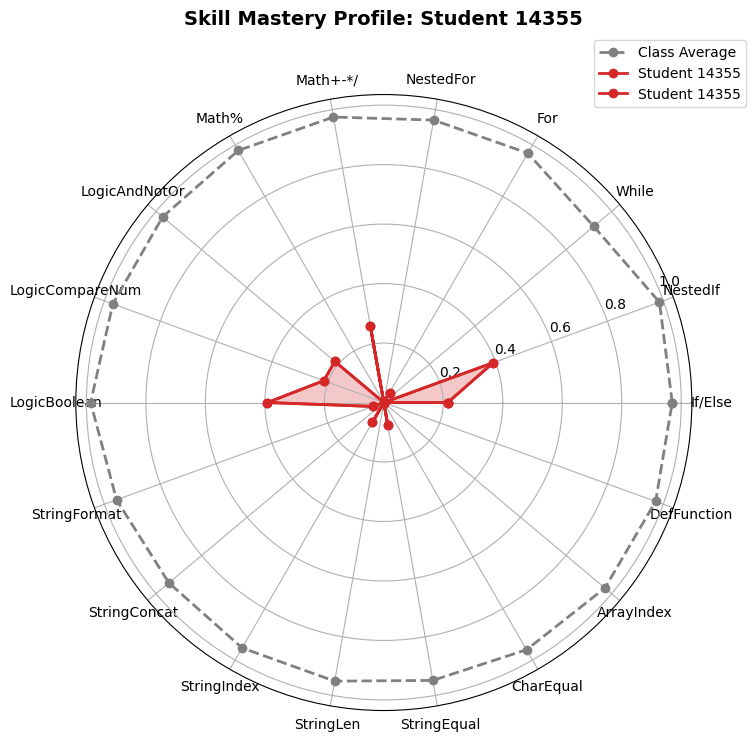


--- 🚨 Verified Skill Gaps for 14355 ---
🔴 For            :   3.8% (Class Avg: 96.8%) -> Gap: -93.0%
🔴 StringFormat   :   3.8% (Class Avg: 95.6%) -> Gap: -91.8%
🔴 StringIndex    :   7.7% (Class Avg: 95.3%) -> Gap: -87.6%
🔴 StringEqual    :   7.7% (Class Avg: 94.9%) -> Gap: -87.2%
🔴 If/Else        :  21.5% (Class Avg: 97.0%) -> Gap: -75.5%
🔴 LogicAndNotOr  :  21.5% (Class Avg: 97.1%) -> Gap: -75.6%
🔴 LogicCompareNum:  21.5% (Class Avg: 97.0%) -> Gap: -75.5%
🔴 Math+-*/       :  26.1% (Class Avg: 97.5%) -> Gap: -71.4%
🔴 NestedIf       :  39.1% (Class Avg: 98.6%) -> Gap: -59.5%
🔴 LogicBoolean   :  39.1% (Class Avg: 98.6%) -> Gap: -59.5%


In [ ]:
# 5. Student Skill Modeling & Visualization
import matplotlib.pyplot as plt
import numpy as np

def load_skill_map():
    """Loads the problem_prompts.csv to map ProblemID to Skills."""
    prompts_path = "dataset/CodeWorkout/Problem_Prompts/problem_prompts.csv"
    try:
        skill_df = pd.read_csv(prompts_path)
        # Identify skill columns (columns after 'Requirement' that are boolean/binary)
        # Based on your CSV structure: properties start from 4th column
        skill_cols = skill_df.columns[3:]
        
        # Melt or organize into a lookup dict: ProblemID -> [List of Skills]
        skill_map = {}
        for _, row in skill_df.iterrows():
            prob_id = row['ProblemID']
            required_skills = [skill for skill in skill_cols if row[skill] == 1.0]
            skill_map[prob_id] = required_skills
            
        return skill_map, list(skill_cols)
    except Exception as e:
        print(f"Error loading skill map: {e}")
        return {}, []

def calculate_student_profile(student_id, attempts_df, skill_map, all_skills):
    """
    Calculates a mastery score (0.0 - 1.0) for each skill based on problem scores.
    """
    student_work = attempts_df[attempts_df['SubjectID'] == student_id]
    
    skill_scores = {skill: [] for skill in all_skills}
    
    for _, row in student_work.iterrows():
        prob_id = row['ProblemID']
        score = row['Score']
        
        # Get skills for this problem
        if prob_id in skill_map:
            for skill in skill_map[prob_id]:
                skill_scores[skill].append(score)
    
    # Average the scores for each skill
    profile = {}
    for skill, scores in skill_scores.items():
        if scores:
            profile[skill] = sum(scores) / len(scores)
        else:
            profile[skill] = 0.0 # Or None if you want to distinguish "no attempt"
            
    return profile

# Load Data
skill_map, all_skills = load_skill_map()

# 1. Calculate Profile for Target Student (14355)
target_profile = calculate_student_profile(
    TARGET_STUDENT_ID, 
    best_attempts_df, 
    skill_map, 
    all_skills
)

# 2. Calculate Class Average Profile
# We'll take a sample of all attempts to estimate 'Average Mastery'
class_profile = {skill: [] for skill in all_skills}
for pid, skills in skill_map.items():
    # Find all attempts for this problem across class
    prob_attempts = best_attempts_df[best_attempts_df['ProblemID'] == pid]
    if not prob_attempts.empty:
        avg_score = prob_attempts['Score'].mean()
        for skill in skills:
            class_profile[skill].append(avg_score)

avg_profile_final = {k: (sum(v)/len(v) if v else 0) for k, v in class_profile.items()}

# --- Visualization: Radar Chart ---
def plot_radar_chart(student_profile, avg_profile, skills, student_id=None):
    if student_id is None:
        student_id = TARGET_STUDENT_ID

    # Filter out skills with 0 data involved to keep chart clean
    active_skills = [s for s in skills if student_profile.get(s, 0) > 0 or avg_profile.get(s, 0) > 0]
    
    if not active_skills:
        print("No skill data available to plot.")
        return

    # Data Prep
    labels = np.array(active_skills)
    stats_student = np.array([student_profile.get(s, 0) for s in active_skills])
    stats_avg = np.array([avg_profile.get(s, 0) for s in active_skills])

    # Close the loop for radar chart
    stats_student = np.concatenate((stats_student, [stats_student[0]]))
    stats_avg = np.concatenate((stats_avg, [stats_avg[0]]))
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Draw Class Average
    ax.plot(angles, stats_avg, 'o-', linewidth=2, linestyle='dashed', color='gray', label='Class Average')
    ax.plot(angles, stats_student, 'o-', linewidth=2, color='#d62728', label=f'Student {student_id}')
    
    # Draw Student
    ax.plot(angles, stats_student, 'o-', linewidth=2, color='#d62728', label=f'Student {TARGET_STUDENT_ID}')
    ax.fill(angles, stats_student, alpha=0.25, color='#d62728')
    ax.set_title(f"Skill Mastery Profile: Student {student_id}", y=1.1, fontsize=14, fontweight='bold')
    # Labels and Formatting
    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_title(f"Skill Mastery Profile: Student {TARGET_STUDENT_ID}", y=1.1, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    ax.grid(True)
    
    plt.show()

print("\nGenerating Skill Model Radar Chart...")
plot_radar_chart(target_profile, avg_profile_final, all_skills)

# Print Text Summary of Weakest Skills
print(f"\n--- 🚨 Verified Skill Gaps for {TARGET_STUDENT_ID} ---")
sorted_skills = sorted(target_profile.items(), key=lambda x: x[1])
for skill, score in sorted_skills:
    if score < 0.6 and score > 0.0: # Filter for attempted but failed
        class_avg = avg_profile_final.get(skill, 0)
        gap = class_avg - score
        print(f"🔴 {skill:<15}: {score*100:5.1f}% (Class Avg: {class_avg*100:.1f}%) -> Gap: -{gap*100:.1f}%")


Generating Mental Model Graph...


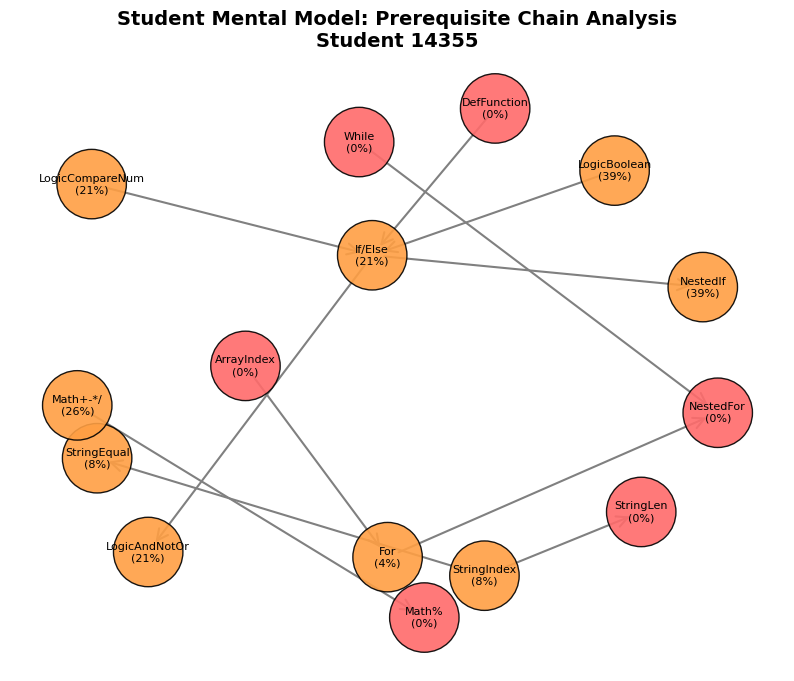

In [33]:
import networkx as nx

def plot_prior_knowledge_graph(student_profile, student_id=None):
    if student_id is None:
        student_id = TARGET_STUDENT_ID

    """
    Visualizes the student's 'Mental Model' by mapping their skill gaps 
    onto a prerequisite dependency graph.
    """
    # Define simplified prerequisite logic (A -> B means A is needed for B)
    # This is a heuristic model based on standard CS curriculum
    dependencies = [
        ("If/Else", "NestedIf"),
        ("If/Else", "LogicAndNotOr"),
        ("LogicCompareNum", "If/Else"),
        ("LogicBoolean", "If/Else"),
        ("While", "NestedFor"),
        ("For", "NestedFor"),
        ("ArrayIndex", "For"), # iterating arrays
        ("StringIndex", "StringLen"),
        ("StringIndex", "StringEqual"),
        ("DefFunction", "If/Else"), # usually functions contain logic
        ("Math+-*/", "Math%"),
    ]

    G = nx.DiGraph()
    G.add_edges_from(dependencies)

    # Determine colors based on mastery
    node_colors = []
    labels = {}
    
    # Identify all relevant nodes (skills in graph OR in profile)
    all_graph_nodes = list(G.nodes)
    
    for node in all_graph_nodes:
        if node in student_profile:
            score = student_profile[node]
            # Color Logic: Red (0.0) -> Yellow (0.5) -> Green (1.0)
            # Differentiate 0 score (failed) from unattempted (if we had that info)
            # Here we assume 0 means struggled or unattempted
            if score < 0.01:
                 color = "#ff6b6b" # Treat 0 as effectively failed/struggling for this view
            elif score < 0.6:
                color = "#ff9f43" # Orange
            elif score < 0.8:
                color = "#feca57" # Yellow
            else:
                color = "#1dd1a1" # Green
        else:
            color = "#d3d3d3" # Default grey if skill not trackable
            
        node_colors.append(color)
        labels[node] = f"{node}\n({student_profile.get(node, 0)*100:.0f}%)"

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42, k=1.5) # Consistent layout, spread out
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, alpha=0.9, edgecolors='black')
    
    # Draw Edges
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color="gray", width=1.5)
    
    plt.title(f"Student Mental Model: Prerequisite Chain Analysis\nStudent {student_id}", fontsize=14, fontweight='bold')
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family='sans-serif')
    
    plt.title(f"Student Mental Model: Prerequisite Chain Analysis\nStudent {TARGET_STUDENT_ID}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

print("\nGenerating Mental Model Graph...")
plot_prior_knowledge_graph(target_profile)

# 6. Thesis Scale-Up: Smart Sampling (Clustering)
To avoid the cost of running LLM analysis on every single student, we perform **K-Means Clustering** to identify representative students ("Archetypes") from the population.

This allows you to validate your thesis on just 3-4 students (Struggling, Average, High Performer) while ensuring they statistically represent the entire class.

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("\n--- Smart Sampling for Thesis Validation ---")

# 1. Build Feature Matrix for ALL Students
# We need a DataFrame where index=StudentID, columns=SkillScores
# We already have 'calculate_student_profile', let's apply it to everyone.
# Note: This might take 5-10 seconds for a large class.

all_student_ids = best_attempts_df['SubjectID'].unique()
print(f"Profiling {len(all_student_ids)} students...")

student_profiles = []
valid_ids = []

for sid in all_student_ids:
    # Quick profile calculation
    prof = calculate_student_profile(sid, best_attempts_df, skill_map, all_skills)
    
    # Check if student has enough data (at least 1 non-zero skill)
    if sum(prof.values()) > 0:
        student_profiles.append(list(prof.values()))
        valid_ids.append(sid)

# Create Feature Matrix (X)
X = np.array(student_profiles)
if len(valid_ids) > 0:
    feature_names = list(calculate_student_profile(valid_ids[0], best_attempts_df, skill_map, all_skills).keys())

    # 2. Perform K-Means Clustering (3 Clusters: Low, Mid, High)
    # We normalize data first to ensure fair distance calculation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Simple logic to handle small datasets (if < 3 students, reduce clusters)
    n_clusters = min(3, len(valid_ids))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    # 3. Find Representative Students (Closest to Centroids)
    representatives = {}

    print(f"\n--- Cluster Analysis Results (N={len(valid_ids)}) ---")

    for i in range(n_clusters):
        # Find indices of students in this cluster
        cluster_indices = np.where(clusters == i)[0]
        
        # Calculate average score for this cluster to name it
        cluster_avg_score = np.mean(X[cluster_indices])
        
        if cluster_avg_score < 0.4:
            label = "⚠️ Struggling Group"
        elif cluster_avg_score > 0.8:
            label = "🌟 High Performers"
        else:
            label = "🔄 Average Group"
        
        # Find the student closest to the centroid (The "Archetype")
        # We calculate distance of each point in this cluster to the center
        cluster_center = kmeans.cluster_centers_[i]
        distances = np.linalg.norm(X_scaled[cluster_indices] - cluster_center, axis=1)
        
        # Get the index of the min distance
        rep_idx_local = np.argmin(distances)
        rep_student_id = valid_ids[cluster_indices[rep_idx_local]]
        
        representatives[label] = rep_student_id
        
        print(f"\n[{label}]")
        print(f"  - Size: {len(cluster_indices)} students")
        print(f"  - Avg Mastery: {cluster_avg_score*100:.1f}%")
        print(f"  - Representative Student: {rep_student_id}")

    print("\n------------------------------------------------")
    print("run the full 'Experiment 3' analysis on these specific students:")
    for label, sid in representatives.items():
        print(f"  -> {label}: {sid}") 
else:
    print("Not enough student data to perform clustering.")


--- Smart Sampling for Thesis Validation ---
Profiling 372 students...

--- Cluster Analysis Results (N=368) ---

[🔄 Average Group]
  - Size: 44 students
  - Avg Mastery: 65.3%
  - Representative Student: 14359

[🌟 High Performers]
  - Size: 315 students
  - Avg Mastery: 96.4%
  - Representative Student: 14475

[⚠️ Struggling Group]
  - Size: 9 students
  - Avg Mastery: 39.5%
  - Representative Student: 10155

------------------------------------------------
run the full 'Experiment 3' analysis on these specific students:
  -> 🔄 Average Group: 14359
  -> 🌟 High Performers: 14475
  -> ⚠️ Struggling Group: 10155


/mnt/d/Projects/kintsugi/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/d/Projects/kintsugi/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


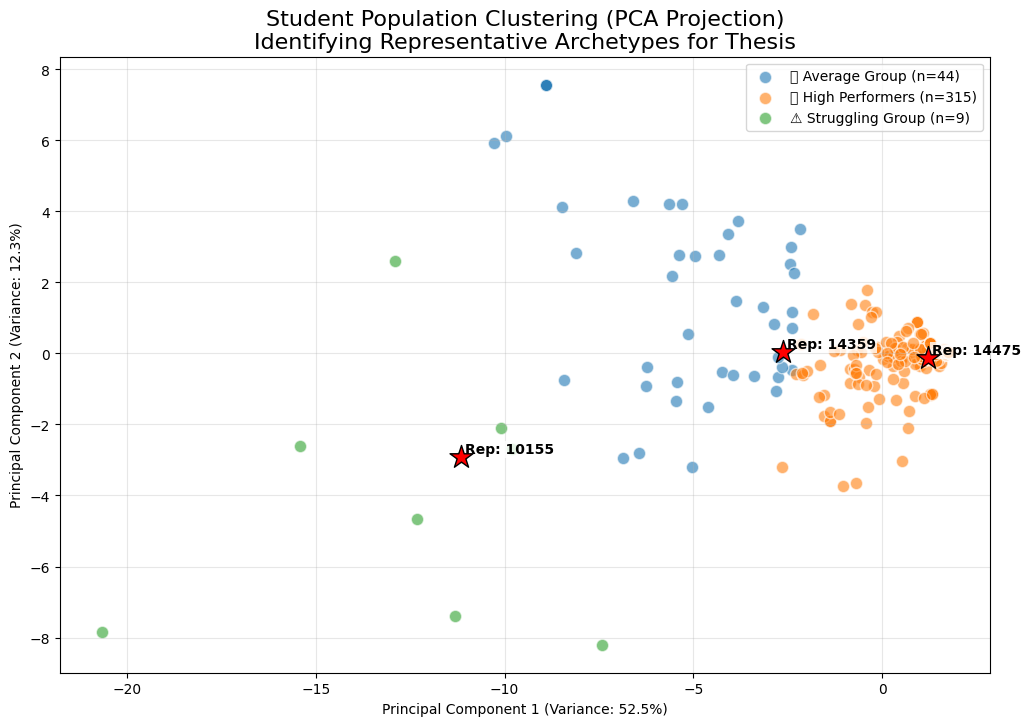

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_student_clusters(X_scaled, clusters, valid_ids, representatives):
    # Reduce dimensions to 2D for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(12, 8))
    
    # Define colors for clusters
    # 0, 1, 2 depends on how KMeans assigned them, but we have labels in 'representatives'
    # We'll map cluster ID to label by checking which label contains a student from that cluster
    
    cluster_map = {}
    for label, rep_id in representatives.items():
        # Find which cluster this rep belongs to
        rep_idx = valid_ids.index(rep_id)
        cluster_id = clusters[rep_idx]
        cluster_map[cluster_id] = label

    colors = ['#ff9f43', '#54a0ff', '#1dd1a1'] # Orange, Blue, Green
    
    # Plot each cluster
    unique_clusters = sorted(list(set(clusters)))
    for c_id in unique_clusters:
        mask = clusters == c_id
        label_name = cluster_map.get(c_id, f"Cluster {c_id}")
        
        plt.scatter(
            X_pca[mask, 0], 
            X_pca[mask, 1], 
            label=f"{label_name} (n={sum(mask)})",
            alpha=0.6,
            edgecolors='w',
            s=80
        )
        
    # Highlight Representatives
    for label, rep_id in representatives.items():
        rep_idx = valid_ids.index(rep_id)
        plt.scatter(
            X_pca[rep_idx, 0], 
            X_pca[rep_idx, 1], 
            c='red', 
            marker='*', 
            s=300, 
            edgecolors='black', 
            zorder=10
        )
        plt.text(
            X_pca[rep_idx, 0] + 0.1, 
            X_pca[rep_idx, 1] + 0.1, 
            f"Rep: {rep_id}", 
            fontsize=10, 
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
        )

    plt.title("Student Population Clustering (PCA Projection)\nIdentifying Representative Archetypes for Thesis", fontsize=16)
    plt.xlabel(f"Principal Component 1 (Variance: {pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"Principal Component 2 (Variance: {pca.explained_variance_ratio_[1]:.1%})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run Plot
if len(valid_ids) > 2:
    plot_student_clusters(X_scaled, clusters, valid_ids, representatives)
else:
    print("Not enough data to visualize clusters.")


📊 GENERATING THESIS CASE STUDIES


>>> 🟢 CASE STUDY: 🔄 Average Group
    Student ID: 14359
    Generating Skill Gap Analysis for 14359...


/tmp/ipykernel_49984/555188872.py:104: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, stats_avg, 'o-', linewidth=2, linestyle='dashed', color='gray', label='Class Average')


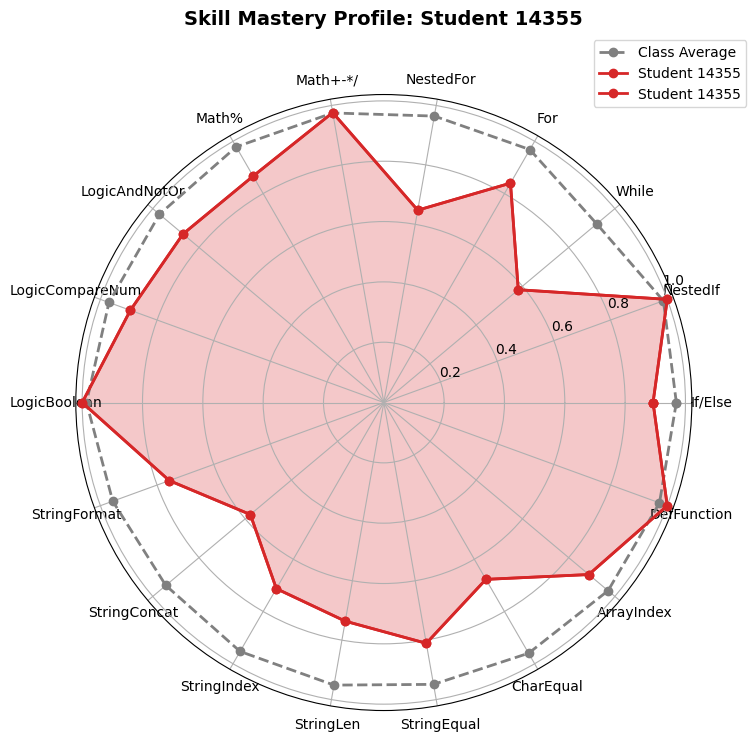

    Mapping Mental Model for 14359...


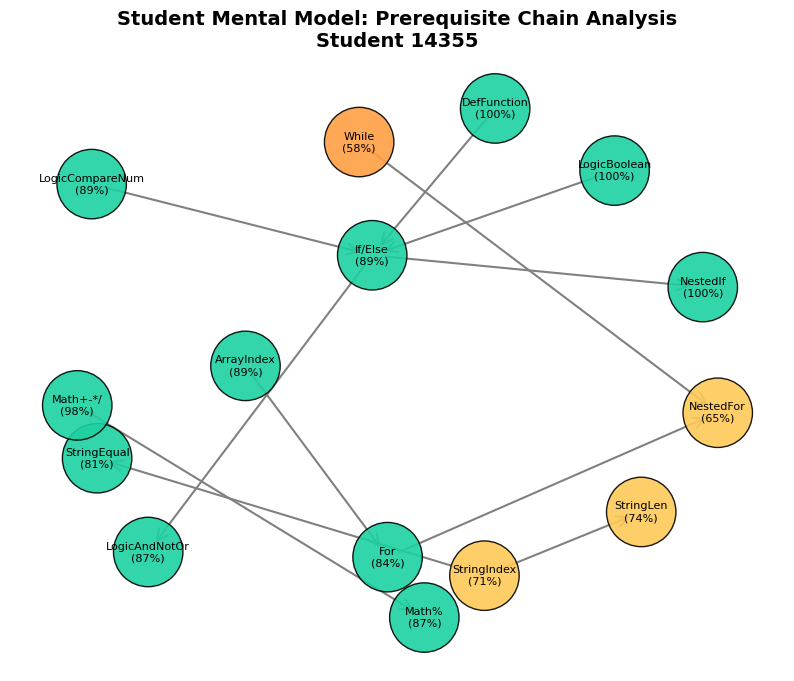

--- End of Report for 14359 ---



>>> 🟢 CASE STUDY: 🌟 High Performers
    Student ID: 14475
    Generating Skill Gap Analysis for 14475...


/tmp/ipykernel_49984/555188872.py:104: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, stats_avg, 'o-', linewidth=2, linestyle='dashed', color='gray', label='Class Average')


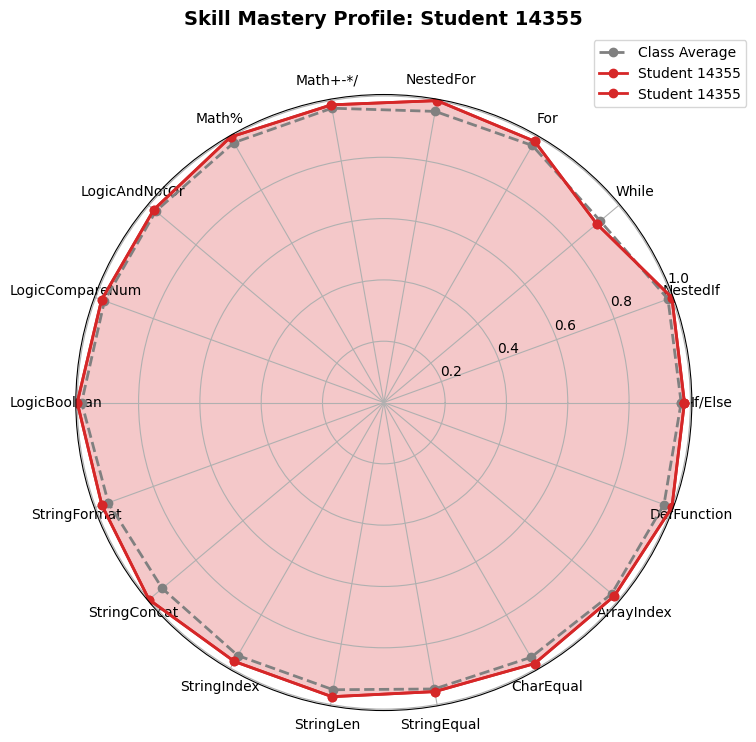

    Mapping Mental Model for 14475...


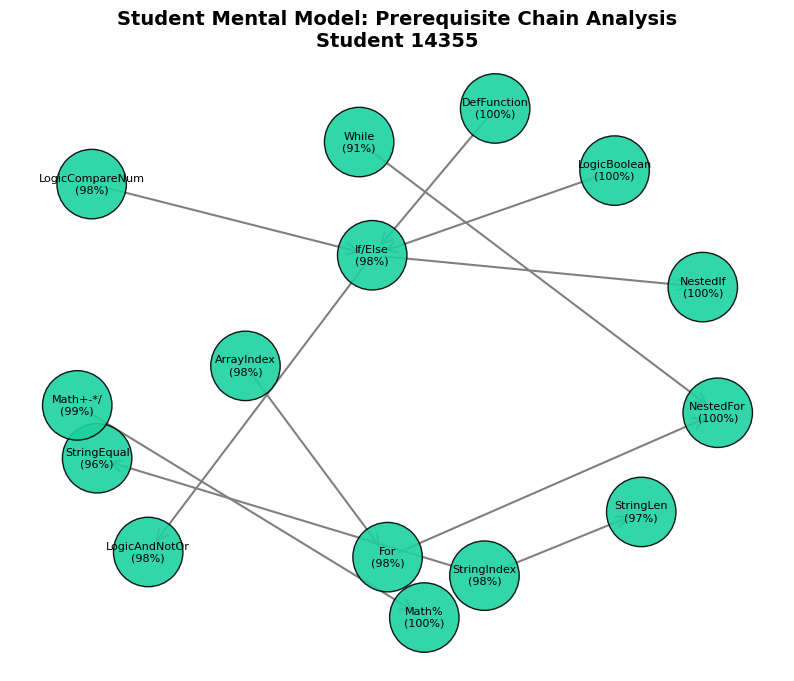

--- End of Report for 14475 ---



>>> 🟢 CASE STUDY: ⚠️ Struggling Group
    Student ID: 10155
    Generating Skill Gap Analysis for 10155...


/tmp/ipykernel_49984/555188872.py:104: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, stats_avg, 'o-', linewidth=2, linestyle='dashed', color='gray', label='Class Average')


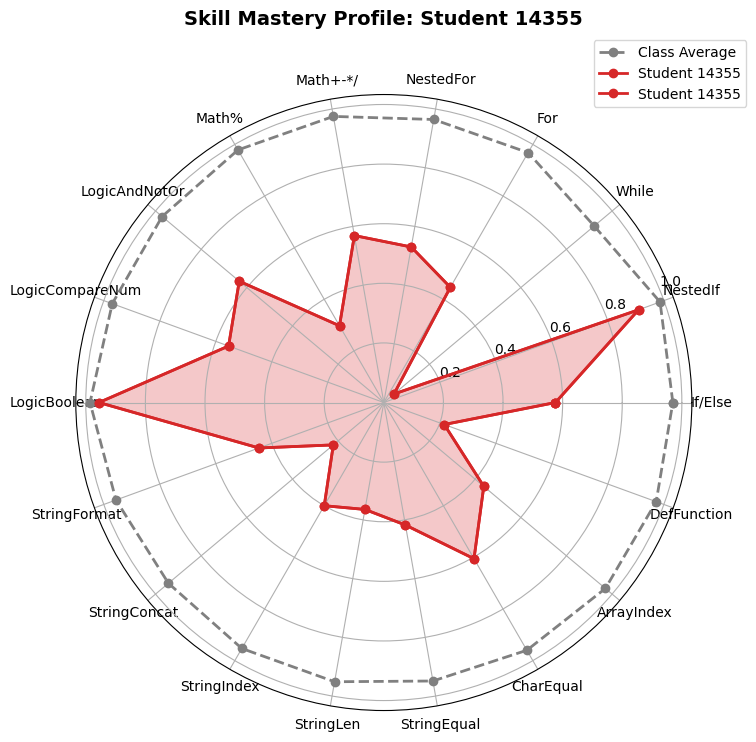

    Mapping Mental Model for 10155...


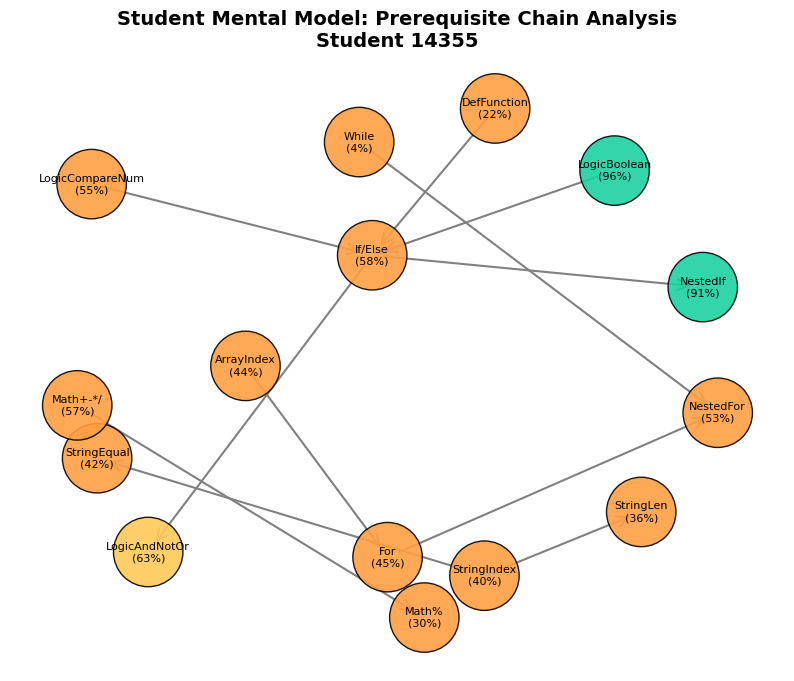

--- End of Report for 10155 ---



In [24]:
# 7. Thesis Case Studies: Automated Report Generation
print("\n" + "="*50)
print("📊 GENERATING THESIS CASE STUDIES")
print("="*50)

for group_label, student_id in representatives.items():
    print(f"\n\n>>> 🟢 CASE STUDY: {group_label}")
    print(f"    Student ID: {student_id}")
    
    # 1. Calculate Individual Profile
    student_profile = calculate_student_profile(student_id, best_attempts_df, skill_map, all_skills)
    
    # 2. Generate Radar Chart (Vs Class Average)
    print(f"    Generating Skill Gap Analysis for {student_id}...")
    plot_radar_chart(student_profile, avg_profile_final, all_skills)
    
    # 3. Generate Mental Model Graph
    print(f"    Mapping Mental Model for {student_id}...")
    plot_prior_knowledge_graph(student_profile)
    
    print(f"--- End of Report for {student_id} ---\n")


📊 GENERATING THESIS CASE STUDIES


>>> 🟢 CASE STUDY: 🔄 Average Group
    Student ID: 14359
    Generating Skill Gap Analysis for 14359...


/tmp/ipykernel_49984/817375747.py:104: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, stats_avg, 'o-', linewidth=2, linestyle='dashed', color='gray', label='Class Average')


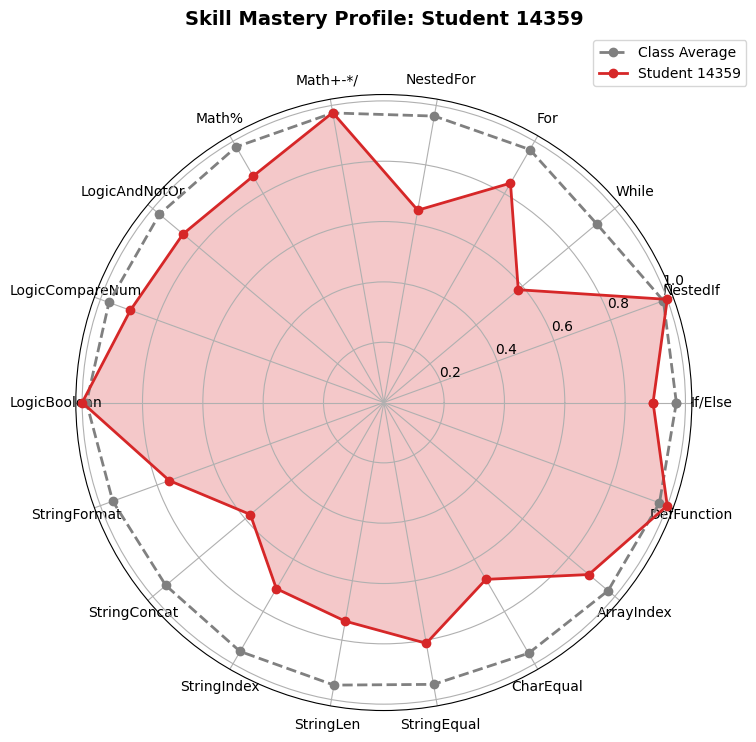

    Mapping Mental Model for 14359...


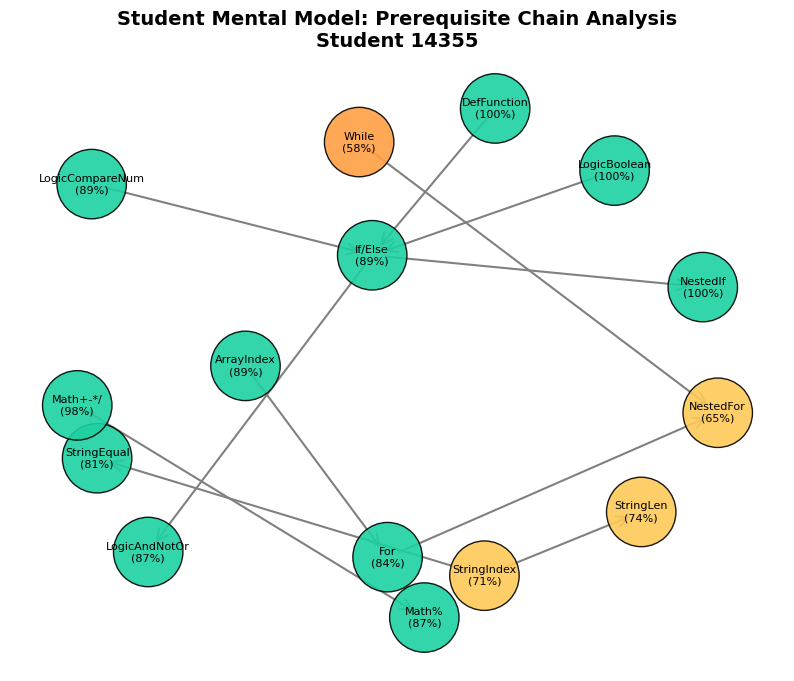

--- End of Report for 14359 ---



>>> 🟢 CASE STUDY: 🌟 High Performers
    Student ID: 14475
    Generating Skill Gap Analysis for 14475...


/tmp/ipykernel_49984/817375747.py:104: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, stats_avg, 'o-', linewidth=2, linestyle='dashed', color='gray', label='Class Average')


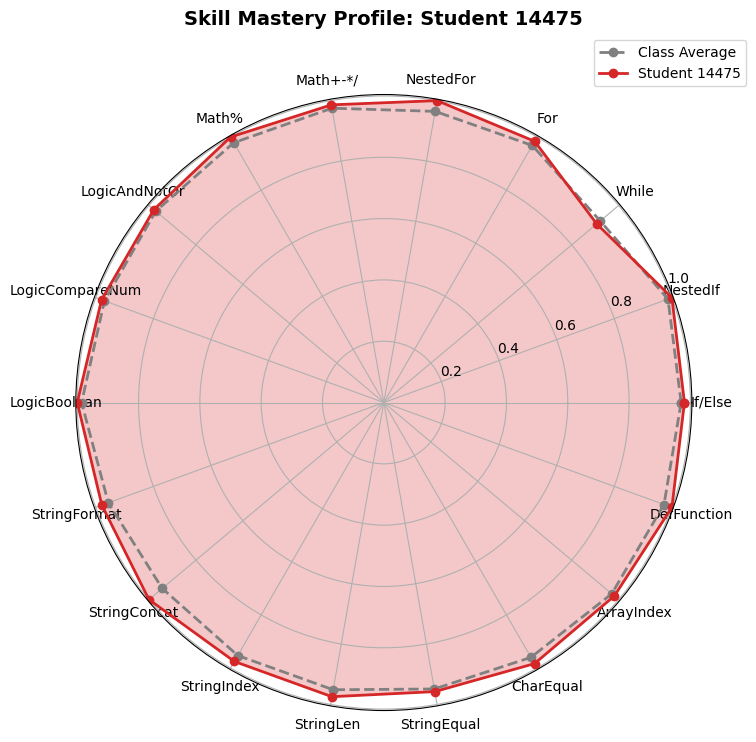

    Mapping Mental Model for 14475...


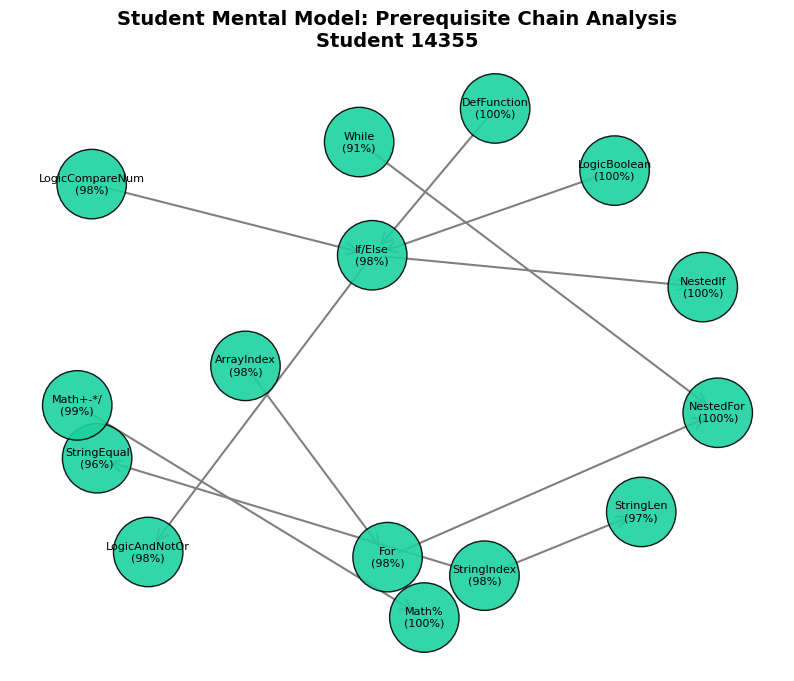

--- End of Report for 14475 ---



>>> 🟢 CASE STUDY: ⚠️ Struggling Group
    Student ID: 10155
    Generating Skill Gap Analysis for 10155...


/tmp/ipykernel_49984/817375747.py:104: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, stats_avg, 'o-', linewidth=2, linestyle='dashed', color='gray', label='Class Average')


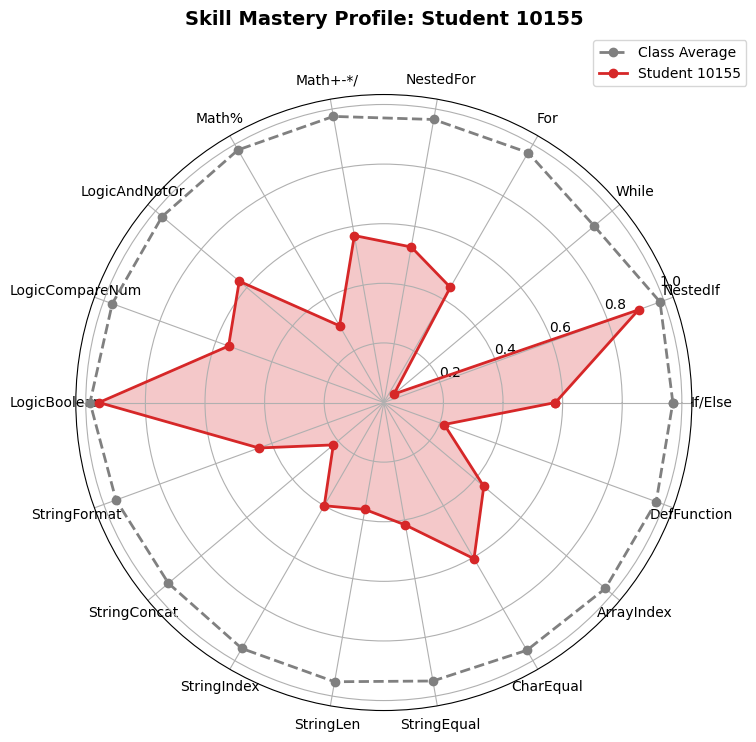

    Mapping Mental Model for 10155...


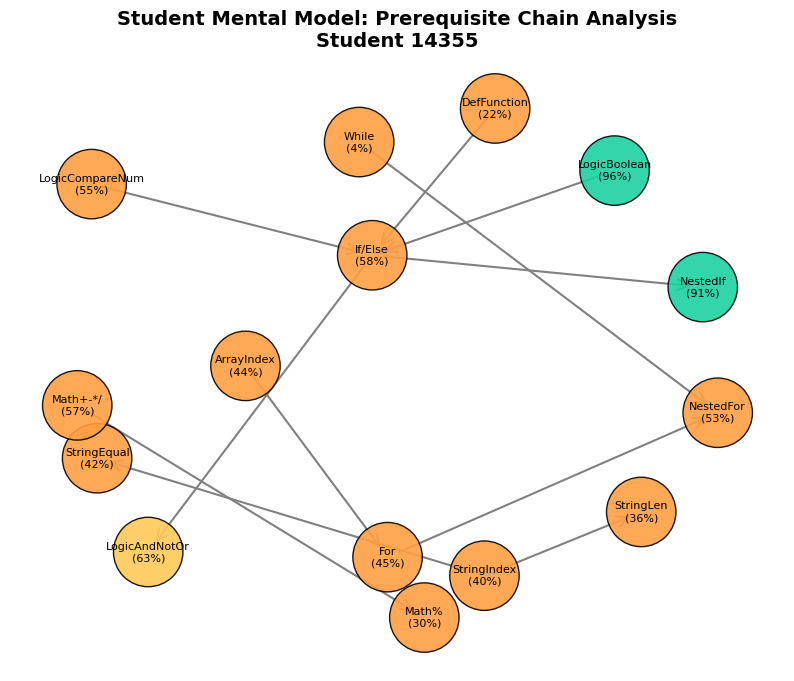

--- End of Report for 10155 ---



In [35]:
# 7. Thesis Case Studies: Automated Report Generation
print("\n" + "="*50)
print("📊 GENERATING THESIS CASE STUDIES")
print("="*50)

for group_label, student_id in representatives.items():
    print(f"\n\n>>> 🟢 CASE STUDY: {group_label}")
    print(f"    Student ID: {student_id}")
    
    # 1. Calculate Individual Profile
    student_profile = calculate_student_profile(student_id, best_attempts_df, skill_map, all_skills)
    
    # 2. Generate Radar Chart (Vs Class Average)
    print(f"    Generating Skill Gap Analysis for {student_id}...")
    plot_radar_chart(student_profile, avg_profile_final, all_skills, student_id=student_id)
    
    # 3. Generate Mental Model Graph
    print(f"    Mapping Mental Model for {student_id}...")
    plot_prior_knowledge_graph(student_profile, student_id=student_id)
    
    print(f"--- End of Report for {student_id} ---\n")